In [2]:
from sstadex import Macromodel, Test, cs_pmos, Primitive, dfs, simplediffpair, cm_pmos, spice_sim
from sympy import Symbol
from sympy import lambdify

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from matplotlib.colors import LogNorm

import paretoset as pareto

import seaborn as sns
sns.set_theme()
sns.color_palette("mako")

sys.path.insert(0, "../../..")
from gmid.mosplot import load_lookup_table, LoadMosfet

# LDO with IHP-SG13G2 low voltage, simple topology

In [3]:
## Exploration parameters

N_points = 10
lengths_nmos = [0.4e-06, 0.8e-06, 1.6e-06, 3.2e-06, 6.4e-6]
lengths_pmos = [0.4e-06, 0.8e-06, 1.6e-06, 3.2e-06, 6.4e-6]

lut_file = "../../LUTs/sky130A_LUT_lvt.npy"
lut_w = 20e-6

## Electrical parameters

Vout = 1.2                                      # LDO output voltage
Vin = 1.8                                       # LDO supply voltage
Vref = 0.9                                      # LDO voltage reference
IL = 5e-3                                     # Load current
CL = 0.5e-12                                    # Load capacitance
RL = Vout/IL

## LDO specifications

efficiency = 0.98
psrr_condition = -70
estability_condition = 60
linereg_condition = 0.5
loadreg_condition = 0.7
#iq_condition = 20e-6
size_condition = 1e-3

I_bias = 5e-6
I_amp1 = 10e-6 # considering the two branches of differential pair
I_amp2 = 10e-6

Iq_max = IL*(1-efficiency)
Ib_pt = Iq_max-I_amp1-I_amp2-I_bias

R1 = (Vout-Vref)/Ib_pt
R2 = Vref*R1/(Vout-Vref)

LDO = pd.DataFrame.from_dict({'Vout': [Vout], 'Vin': [Vin], 'Vref': [Vref], 'IL': [IL], 'CL': [CL], 'RL': [RL], 'Iq_max': [Iq_max], 'Ib_pt': [Ib_pt], 'R1': [R1], 'R2': [R2]}, orient='index', columns=['Value'])
LDO

,Value
Vout,1.200000e+00
Vin,1.800000e+00
Vref,9.000000e-01
IL,5.000000e-03
CL,5.000000e-13
RL,2.400000e+02
Iq_max,1.000000e-04
Ib_pt,7.500000e-05
R1,4.000000e+03
R2,1.200000e+04


# Step 1: Pre-exploration

## Macromodels Definition

In [4]:
Vota = np.linspace(Vout-0.8, Vout+0.5, N_points)
Vota_1stage = np.linspace(Vout-0.3, Vout+0.5, 5)

In [5]:
LDO_macro = Macromodel(
    name ='LDO_macro', 
    outputs= [
        Symbol("W_2stage"), Symbol("L_2stage"),
        Symbol("vin_2stage"),
        Symbol('W_cs_2stage'), Symbol('L_cs_2stage'),
        Symbol('vgs_cs_2stage'),
        Symbol("W_diff"), Symbol("L_diff"), 
        Symbol("vout_1stage"),
        Symbol("W_al"), Symbol("L_al"),
        Symbol("W_cs"), Symbol("L_cs"),
        Symbol('vgs_cs'),
        Symbol("W_pt"), Symbol("L_pt"),
        Symbol("W_cc"), Symbol("L_cc"),
        Symbol("W_rc"), Symbol("L_rc")],
    electrical_parameters={
        "Vdd": Vin, 
        "Vref": Vref, 
        "Vout": Vout, 
        "Vota": Vota,
        "Il": IL+Ib_pt}
    )

OTA_macro = Macromodel(
    name = 'OTA_macro',
    outputs = [
        Symbol("W_2stage"), Symbol("L_2stage"),
        Symbol("vin_2stage"),
        Symbol('W_cs_2stage'), Symbol('L_cs_2stage'),
        Symbol('vgs_cs_2stage'),
        Symbol("W_diff"), Symbol("L_diff"), 
        Symbol("vout_1stage"),
        Symbol("W_al"), Symbol("L_al"),
        Symbol("W_cs"), Symbol("L_cs"),
        Symbol('vgs_cs'),
        Symbol("W_cc"), Symbol("L_cc"),
        Symbol("W_rc"), Symbol("L_rc")],
    electrical_parameters = {
        "Vdd": LDO_macro.electrical_parameters["Vdd"],
        "Vref": LDO_macro.electrical_parameters["Vref"],
        "Vout": LDO_macro.electrical_parameters["Vota"],
        "Vota_1stage": Vota_1stage,
        "Il": I_amp2},
    macromodel_parameters={
        Symbol('Ra'): np.logspace(3, 7, N_points),
        Symbol('gma'): np.logspace(-5, -2, N_points)}
    )

OTA_2stage_macro = Macromodel(
    name = 'OTA_2stage_macro',
    outputs = [
        Symbol("W_2stage"), Symbol("L_2stage"),
        Symbol("vin_2stage"),
        Symbol('W_cs_2stage'), Symbol('L_cs_2stage'),
        Symbol('vgs_cs_2stage')],
    electrical_parameters = {
        "Vdd": OTA_macro.electrical_parameters["Vdd"],
        "Vin": OTA_macro.electrical_parameters["Vota_1stage"],
        "Vout": OTA_macro.electrical_parameters["Vout"],
        "Il": I_amp2},
    macromodel_parameters={
        Symbol('Ra_2stage'): np.logspace(3, 7, 5),
        Symbol('gma_2stage'): np.logspace(-5, -2, 5),
        Symbol('Cin_2stage'): np.logspace(-16, -11, 5)}
    )

OTA_1stage_macro = Macromodel(
    name = 'OTA_1stage_macro',
    outputs = [
        Symbol("W_diff"), Symbol("L_diff"), 
        Symbol("vout_1stage"),
        Symbol("W_al"), Symbol("L_al"),
        Symbol("W_cs"), Symbol("L_cs"),
        Symbol('vgs_cs')],
    electrical_parameters = {
        "Vdd": OTA_macro.electrical_parameters["Vdd"],
        "Vref": OTA_macro.electrical_parameters["Vref"],
        "Vout": OTA_macro.electrical_parameters["Vota_1stage"],
        "Il": I_amp1},
    macromodel_parameters={
        Symbol('Ra_1stage'): np.logspace(3, 7, N_points),
        Symbol('gma_1stage'): np.logspace(-5, -2, N_points)}
    ) 

## Testbenches

### LDO testbenches

In [6]:
psrr_LDO_macro = Test()
psrr_LDO_macro.name = "psrr_LDO"
psrr_LDO_macro.tf = ["vout", "vdd"]
psrr_LDO_macro.netlist = "ldo"
psrr_LDO_macro.parametros = {Symbol("V1"): 1,
                             Symbol("V2"): 0,
                             Symbol("s"): 0,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): RL,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2}

psrr_LDO_macro.opt_goal = "min"
psrr_LDO_macro.conditions = {"max": [10**(100/20)]}
psrr_LDO_macro.variables = {}
psrr_LDO_macro.out_def = {"eval": psrr_LDO_macro.tf}

##############################################################################

dc_LDO_macro = Test()
dc_LDO_macro.name = "dc_LDO"
dc_LDO_macro.tf = ["vout", "vdd"]
dc_LDO_macro.netlist = "ldo"
dc_LDO_macro.parametros = {Symbol("V1"): Vin,
                           Symbol("V2"): Vref,
                           Symbol("s"): 0,
                           Symbol("Rl"): RL,
                           Symbol("Cl"): CL,
                           Symbol("R1"): R1, 
                           Symbol("R2"): R2}

dc_LDO_macro.opt_goal = "min"
dc_LDO_macro.conditions = {"min": [0]}
dc_LDO_macro.variables = {}
dc_LDO_macro.out_def = {"eval": dc_LDO_macro.tf}
x = Symbol("x")
dc_LDO_macro.lamd = lambdify(x, x*1.8)

##############################################################################

gain_ol_LDO_macro = Test()
gain_ol_LDO_macro.name = "gain_ol_LDO"
gain_ol_LDO_macro.tf = ["vout", "vol"]
gain_ol_LDO_macro.netlist = "ldo_ol"
gain_ol_LDO_macro.parametros = {Symbol("V1"): 0,
                             Symbol("V2"): 0,
                             Symbol("V3"): 1,
                             Symbol("s"): 0,
                             Symbol("C1"): 10,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): RL,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2,
                             Symbol("R3"): 10000000000}

gain_ol_LDO_macro.opt_goal = "min"
gain_ol_LDO_macro.conditions = {"min": [1]}
gain_ol_LDO_macro.variables = {}
gain_ol_LDO_macro.out_def = {"eval": gain_ol_LDO_macro.tf}

##############################################################################

phase_margin_LDO_macro = Test()
phase_margin_LDO_macro.name = "phase_margin_LDO"
phase_margin_LDO_macro.tf = ["vout", "vol"]
phase_margin_LDO_macro.netlist = "ldo_ol"
phase_margin_LDO_macro.parametros = {Symbol("V1"): 0,
                             Symbol("V2"): 0,
                             Symbol("V3"): 1,
                             Symbol("C1"): 10,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): RL,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2,
                             Symbol("R3"): 10000000000}

phase_margin_LDO_macro.opt_goal = "min"
phase_margin_LDO_macro.conditions = {"min": [-300]}
phase_margin_LDO_macro.variables = {}
phase_margin_LDO_macro.out_def = {"pm": phase_margin_LDO_macro.tf}

### OTA testbenches

In [7]:
gain_OTA = Test()
gain_OTA.name = "gain_OTA"
gain_OTA.tf = ["vout", "vpos"]
gain_OTA.netlist = "OpAmp_2stage"
gain_OTA.parametros = {
    Symbol("V1"): 0,
    Symbol("Vpos"): 1,
    Symbol("I_amp2"): 0,
    Symbol("s"): 0}

gain_OTA.opt_goal = "max"
gain_OTA.conditions = {"min": [10**(-100/20)]}
gain_OTA.variables = {}
gain_OTA.out_def = {"eval": gain_OTA.tf}

#########################################################

phase_margin_OTA = Test()
phase_margin_OTA.name = "phase_margin_OTA"
phase_margin_OTA.tf = ["vout", "vpos"]
phase_margin_OTA.netlist = "OpAmp_2stage"
phase_margin_OTA.parametros = {
    Symbol("V1"): 0,
    Symbol("Vpos"): 1,
    Symbol("Cin_pt"): 1e-12}

phase_margin_OTA.opt_goal = "min"
phase_margin_OTA.conditions = {"min": [0]}
phase_margin_OTA.variables = {}
phase_margin_OTA.out_def = {"pm": phase_margin_OTA.tf}

##########################################################

rout_OTA = Test()
rout_OTA.name = "rout_OTA"
rout_OTA.target_param = Symbol("Ra")
rout_OTA.tf = ["vout", "vr"]
rout_OTA.netlist = "OpAmp_2stage_rout"
rout_OTA.parametros = {
    Symbol("Vpos"): 0,
    Symbol("Vr"): 1,
    Symbol("s"): 0,
    Symbol("Rr"): 1000,
    Symbol("Cin_pt"): 1e-12}

rout_OTA.opt_goal = "max"
rout_OTA.conditions = {"min": [1]}
x = Symbol("x")
rout_OTA.lamd = lambdify(x, x*1000/(1-x))
rout_OTA.variables = {}
rout_OTA.out_def = {"eval": rout_OTA.tf}

##########################################################

gm_OTA = Test()
gm_OTA.target_param = Symbol("gma")
gm_OTA.name = "gm_OTA"
gm_OTA.tf = ["vout", "vpos"]
gm_OTA.netlist = "OpAmp_2stage"
gm_OTA.composed = 1
gm_OTA.out_def = {"divide": [gain_OTA, rout_OTA]}
gm_OTA.opt_goal = "max"
gm_OTA.conditions = {"min": [0.000000001]}

### OTA 2stage Testbenches

In [8]:
gain_2stage_OTA = Test()
gain_2stage_OTA.tf = ("vout", "vin")
gain_2stage_OTA.name = "gain_2stage"
gain_2stage_OTA.netlist = "ota_2stage_v2"
gain_2stage_OTA.parametros = {
    Symbol("V1"): 0,
    Symbol("V2"): 1,
    Symbol("s"): 0,
    Symbol("Cin_pt"): 1e-12}
gain_2stage_OTA.opt_goal = "max"
gain_2stage_OTA.conditions = {"min": [1]}
gain_2stage_OTA.variables = {}
gain_2stage_OTA.out_def = {"eval": gain_2stage_OTA.tf}

##################################################################

rout_2stage_OTA = Test()
rout_2stage_OTA.name = "rout_2stage"
rout_2stage_OTA.target_param = Symbol("Ra_2stage")
rout_2stage_OTA.tf = ["vout", "vr"]
rout_2stage_OTA.netlist = "ota_2stage_rout_v2"
rout_2stage_OTA.parametros = {Symbol("V1"): 0,
                              Symbol("V2"): 0,
                                Symbol("Vr"): 1,
                                Symbol("s"): 0,
                                Symbol("Rr"): 1000,
                                Symbol("Cin_pt"): 1e-12}

rout_2stage_OTA.opt_goal = "max"
rout_2stage_OTA.conditions = {"min": [1]}
x = Symbol("x")
rout_2stage_OTA.lamd = lambdify(x, x*1000/(1-x))
rout_2stage_OTA.variables = {}
rout_2stage_OTA.out_def = {"eval": rout_2stage_OTA.tf}

##################################################################

gm_2stage_OTA = Test()
gm_2stage_OTA.target_param = Symbol("gma_2stage")
gm_2stage_OTA.name = "gm_2stage"
gm_2stage_OTA.tf = ["vout", "vin"]
gm_2stage_OTA.netlist = "ota_2stage_v2"
gm_2stage_OTA.composed = 1
gm_2stage_OTA.out_def = {"divide": [gain_2stage_OTA, rout_2stage_OTA]}
gm_2stage_OTA.opt_goal = "max"
gm_2stage_OTA.conditions = {"min": [0.000000001]}

### OTA 1stage Testbenches

In [9]:
gain_1stage_OTA = Test()
gain_1stage_OTA.tf = ("vout", "vpos")
gain_1stage_OTA.name = "gain_1stage"
gain_1stage_OTA.netlist = "ota_1stage"
gain_1stage_OTA.parametros = {
    Symbol("gdiff_2"): Symbol("gdiff_1"),
    Symbol("Rdiff_2"): Symbol("Rdiff_1"),
    Symbol("gaload_2"): Symbol("gaload_1"),
    Symbol("Raload_2"): Symbol("Raload_1"),
    Symbol("V1"): 0,
    Symbol("V_n"): 0,
    Symbol("V_p"): 1,
    Symbol("I2"): 0,
    Symbol("s"): 0}
gain_1stage_OTA.opt_goal = "max"
gain_1stage_OTA.conditions = {"min": [10**(-100/20)]}
gain_1stage_OTA.variables = {}
gain_1stage_OTA.out_def = {"eval": gain_1stage_OTA.tf}

##################################################################

psrr_1stage_OTA = Test()
psrr_1stage_OTA.tf = ("vout", "vdd")
psrr_1stage_OTA.name = "psrr_1stage"
psrr_1stage_OTA.netlist = "ota_1stage"
psrr_1stage_OTA.parametros = {
    Symbol("gdiff_2"): Symbol("gdiff_1"),
    Symbol("Rdiff_2"): Symbol("Rdiff_1"),
    Symbol("gaload_2"): Symbol("gaload_1"),
    Symbol("Raload_2"): Symbol("Raload_1"),
    Symbol("V1"): 1,
    Symbol("V_n"): 0,
    Symbol("V_p"): 0,
    Symbol("I2"): 0,
    Symbol("s"): 0}
psrr_1stage_OTA.opt_goal = "max"
psrr_1stage_OTA.conditions = {"min": [0.0000001]}
psrr_1stage_OTA.variables = {}
psrr_1stage_OTA.out_def = {"eval": psrr_1stage_OTA.tf}

##################################################################

rout_1stage_OTA = Test()
rout_1stage_OTA.name = "rout_1stage"
rout_1stage_OTA.target_param = Symbol("Ra_1stage")
rout_1stage_OTA.tf = ["vout", "vr"]
rout_1stage_OTA.netlist = "ota_1stage_rout"
rout_1stage_OTA.parametros = {Symbol("gdiff_2"): Symbol("gdiff_1"),
                              Symbol("Rdiff_2"): Symbol("Rdiff_1"),
                                Symbol("gaload_2"): Symbol("gaload_1"),
                                Symbol("Raload_2"): Symbol("Raload_1"),
                                Symbol("V1"): 0,
                                Symbol("V_n"): 0,
                                Symbol("V_p"): 0,
                                Symbol("Vr"): 1,
                                Symbol("I2"): 0,
                                Symbol("s"): 0,
                                Symbol("Rr"): 1000,
                                Symbol("Cl"): 1e-12}

rout_1stage_OTA.opt_goal = "max"
rout_1stage_OTA.conditions = {"min": [1]}
x = Symbol("x")
rout_1stage_OTA.lamd = lambdify(x, x*1000/(1-x))
rout_1stage_OTA.variables = {}
rout_1stage_OTA.out_def = {"eval": rout_1stage_OTA.tf}

##################################################################

gm_1stage_OTA = Test()
gm_1stage_OTA.target_param = Symbol("gma_1stage")
gm_1stage_OTA.name = "gm_1stage"
gm_1stage_OTA.tf = ["vout", "vpos"]
gm_1stage_OTA.netlist = "ota_1stage"
gm_1stage_OTA.composed = 1
gm_1stage_OTA.out_def = {"divide": [gain_1stage_OTA, rout_1stage_OTA]}
gm_1stage_OTA.opt_goal = "max"
gm_1stage_OTA.conditions = {"min": [9.999999999999999e-6]}

## Primitives definition

### LDO primitives

In [10]:
LDO_macro.electrical_parameters["Vota"]

array([0.4       , 0.54444444, 0.68888889, 0.83333333, 0.97777778,
       1.12222222, 1.26666667, 1.41111111, 1.55555556, 1.7       ])

In [11]:
LDO_macro.electrical_parameters["Vout"]-LDO_macro.electrical_parameters["Vdd"]

-0.6000000000000001

In [12]:
pt = cs_pmos(
    lut_file=lut_file,
    lut_w=lut_w,
    netlist='pmos_cm.spice', 
    type='pmos', 
    inputs={
        'vds_lut': LDO_macro.electrical_parameters["Vout"]-LDO_macro.electrical_parameters["Vdd"], 
        'vgs_lut': (-1.8, -0.1, 0.01), 
        'vgs': LDO_macro.electrical_parameters["Vota"]-Vin, 
        'il': LDO_macro.electrical_parameters["Il"],
        'length': lengths_pmos, 
        '2d_var': ['length', 'vgs']})

pt_df = pt.build()

mask = (pt_df["width"]>5e-6) & (pt_df["width"]<15e-3)

pt_df = pt_df[mask]

pt.parameters = {
    Symbol('gm_pt'): pt_df['gm'].values,
    Symbol('Ro_pt'): pt_df['Ro'].values,
    Symbol("Cgg_pt"): pt_df['cgg'].values,
    Symbol("Cgd_pt"): np.abs(pt_df['cgd'].values),  
    Symbol("Cin_pt"): pt_df['cgg'].values+np.abs(pt_df["cgd"].values)*pt_df["gm"].values*pt_df["Ro"].values,
    Symbol("dropout"): 2/(pt_df["gm"]/pt.inputs['il']),
    Symbol('Vota'): np.tile(LDO_macro.electrical_parameters["Vota"], 5)[mask]}

pt.outputs = {
    Symbol("W_pt"): pt_df["width"].values,
    Symbol("L_pt"): pt_df["length"].values}

# CASE 2: WITHOUT LOAD

## found operation point of the circuit with no load
lookup_table = load_lookup_table(lut_file)

pt_lutable = LoadMosfet(
            lookup_table=lookup_table,
            mos='pmos',
            vsb=0,
            vds=LDO_macro.electrical_parameters["Vout"]-LDO_macro.electrical_parameters["Vdd"],
            vgs=(-2.5, -0.1, 0.01),
            lengths=lengths_pmos,
        )

jd_2 = Ib_pt/pt.W.flatten()

vgs_2 = pt_lutable.interpolate(
            x_expression=pt_lutable.current_density_expression,
            x_value=jd_2,
            y_expression=pt_lutable.lengths_expression,
            y_value=pt.L.flatten(),
            z_expression=pt_lutable.vgs_expression,
        )

vgs_2 = np.diag(vgs_2)
print("Values of Vgs_pt when there is no load: ", vgs_2)
##

vout_2stage_wc = vgs_2

pt_wc = cs_pmos(
    lut_file=lut_file,
    lut_w=lut_w,
    netlist='pmos_cm.spice', 
    type='pmos', 
    inputs={
        'vds_lut': LDO_macro.electrical_parameters["Vout"]-LDO_macro.electrical_parameters["Vdd"], 
        'vgs_lut': (-2, -0.1, 0.01), 
        'vgs': vout_2stage_wc, 
        'il': Ib_pt,
        'length': pt.L.flatten(), 
        '2d_var': ['length', 'vgs']})

pt_wc_df = pt_wc.build()

pt_wc.parameters = {
    Symbol('gm_pt'): pt_wc_df["gm"].values.reshape(50,-1).diagonal().flatten()[mask],
    Symbol('Ro_pt'): pt_wc_df["Ro"].values.reshape(50,-1).diagonal().flatten()[mask],
    Symbol("Cgg_pt"): pt_wc_df["cgg"].values.reshape(50,-1).diagonal().flatten()[mask],
    Symbol("Cgd_pt"): np.abs(pt_wc_df["cgd"].values.reshape(50,-1).diagonal().flatten()[mask]),
    Symbol("dropout"): 2/(pt_wc_df["gm"].values.reshape(50,-1).diagonal().flatten()[mask]/pt_wc.inputs['il']),
    Symbol("Cin_pt"): pt_wc_df["cgg"].values.reshape(50,-1).diagonal().flatten()[mask]
                        +np.abs(pt_wc_df["cgd"].values.reshape(50,-1).diagonal().flatten()[mask])
                        *pt_wc_df["gm"].values.reshape(50,-1).diagonal().flatten()[mask]*pt_wc_df["Ro"].values.reshape(50,-1).diagonal().flatten()[mask],
    Symbol('Vota'): Vin+vout_2stage_wc[mask]}

pt_wc.outputs = {
    Symbol("W_pt"): pt_df["width"].values,
    Symbol("L_pt"): pt_df["length"].values}

length
vgs
0
Values of Vgs_pt when there is no load:  [-0.45021879 -0.42897545 -0.40345725 -0.37306746 -0.33676545 -0.29240655
 -0.23545689 -0.15998946         nan         nan -0.55030426 -0.52645899
 -0.49742221 -0.46226527 -0.41884436 -0.36203327 -0.28389448 -0.18713752
         nan         nan -0.56971559 -0.54454147 -0.5142945  -0.47840886
 -0.43499444 -0.37844444 -0.29868514 -0.1965368          nan         nan
 -0.5698437  -0.54251595 -0.510506   -0.47368827 -0.43032005 -0.37489097
 -0.29668611 -0.19402913         nan         nan -0.57769215 -0.54922983
 -0.5159939  -0.47824493 -0.43419638 -0.3781122  -0.2988985  -0.19463656
         nan         nan]
length
vgs
0


In [13]:
pt.parameters[Symbol("Vota")]

array([0.4       , 0.54444444, 0.68888889, 0.83333333, 0.97777778,
       1.12222222, 1.26666667, 1.41111111, 0.4       , 0.54444444,
       0.68888889, 0.83333333, 0.97777778, 1.12222222, 1.26666667,
       0.4       , 0.54444444, 0.68888889, 0.83333333, 0.97777778,
       1.12222222, 0.4       , 0.54444444, 0.68888889, 0.83333333,
       0.97777778, 1.12222222, 0.4       , 0.54444444, 0.68888889,
       0.83333333, 0.97777778])

### OTA primitives

In [14]:
vs = np.linspace(0.3, 0.8, 5)

Cc = np.logspace(-13, -10, 3)
Rc = np.logspace(3, 5, 3)

mesh = np.meshgrid(Cc, Rc)

Cc_primitive = Primitive(parameters={Symbol("Cc"): mesh[0].flatten(),
                                     Symbol("Rc"): mesh[1].flatten()})
Cc_primitive.outputs = {
    Symbol("W_cc"): np.sqrt(Cc_primitive.parameters[Symbol("Cc")]/1.5e-15)*1e-6,
    Symbol("L_cc"): np.sqrt(Cc_primitive.parameters[Symbol("Cc")]/1.5e-15)*1e-6,
    Symbol("W_rc"): np.sqrt(Cc_primitive.parameters[Symbol("Rc")]/(1360*0.5))*1e-6,
    Symbol("L_rc"): np.repeat(0.5e-6, len(mesh[0].flatten()))}

In [15]:
Cc = np.logspace(-13, -12, 3)
Rc = np.logspace(3, 4, 3)

mesh = np.meshgrid(Cc, Rc)

Cc_primitive_LDO = Primitive(parameters={Symbol("Cc"): mesh[0].flatten(),
                                     Symbol("Rc"): mesh[1].flatten()})
Cc_primitive_LDO.outputs = {
    Symbol("W_cc"): np.sqrt(Cc_primitive_LDO.parameters[Symbol("Cc")]/1.5e-15)*1e-6,
    Symbol("L_cc"): np.sqrt(Cc_primitive_LDO.parameters[Symbol("Cc")]/1.5e-15)*1e-6,
    Symbol("W_rc"): np.sqrt(Cc_primitive_LDO.parameters[Symbol("Rc")]/(1360*0.5))*1e-6,
    Symbol("L_rc"): np.repeat(0.5e-6, len(mesh[0].flatten()))}

### OTA 2stage primitives

In [16]:
OTA_2stage_macro.electrical_parameters["Vin"]

array([0.9, 1.1, 1.3, 1.5, 1.7])

In [17]:
vout_2stage = 1.122-Vin
vout_1stage = OTA_2stage_macro.electrical_parameters["Vin"] - Vin
Cin_pt = 1.38e-11

stage2_t = cs_pmos()
stage2_t.parameters = {
    Symbol('gm_2stage'): [],
    Symbol('Ro_2stage'): [],
    Symbol('Cin_2stage'): [],
    }

stage2_t.outputs = {
    Symbol("W_2stage"): [],
    Symbol("L_2stage"): [],
    Symbol("vin_2stage"): []}

for vds, vgs, Cout in zip(np.repeat(vout_2stage, 5) ,vout_1stage, np.repeat(Cin_pt, 5)):

    stage2_t_aux = cs_pmos(
        lut_file=lut_file,
        lut_w=lut_w,
        netlist='pmos_cs.spice',
        type='pmos',
        inputs={
            'vds_lut': vds, 
            'vgs_lut': (-1.8, -0.1, 0.01), 
            'vgs': vgs, 
            'il': OTA_2stage_macro.electrical_parameters["Il"],
            'length': lengths_pmos, 
            '2d_var': ['length', 'vgs']})

    stage2_t_aux.build()

    print(stage2_t_aux.L)
    print(stage2_t_aux.W)
    print(vds)
    print(vgs)

    stage2_t.parameters[Symbol('gm_2stage')].append(np.asarray(stage2_t_aux.gm).flatten())
    stage2_t.parameters[Symbol('Ro_2stage')].append(np.asarray(stage2_t_aux.Ro).flatten())
    stage2_t.parameters[Symbol('Cin_2stage')].append(np.asarray(stage2_t_aux.cgg).flatten()+np.asarray(stage2_t_aux.gm).flatten()*np.asarray(stage2_t_aux.Ro).flatten()*np.asarray(np.abs(stage2_t_aux.cgd)).flatten())

    stage2_t.outputs[Symbol('W_2stage')].append(np.asarray(stage2_t_aux.W).flatten())
    stage2_t.outputs[Symbol('L_2stage')].append(np.asarray(stage2_t_aux.L).flatten())
    stage2_t.outputs[Symbol('vin_2stage')].append(1.8+np.repeat(vgs, 5))

stage2_t.parameters[Symbol('gm_2stage')] = np.asarray(stage2_t.parameters[Symbol('gm_2stage')]).flatten()
stage2_t.parameters[Symbol('Ro_2stage')] = np.asarray(stage2_t.parameters[Symbol('Ro_2stage')]).flatten()
stage2_t.parameters[Symbol('Cin_2stage')] = np.asarray(stage2_t.parameters[Symbol('Cin_2stage')]).flatten()

stage2_t.outputs[Symbol('W_2stage')] = np.asarray(stage2_t.outputs[Symbol('W_2stage')]).flatten()
stage2_t.outputs[Symbol('L_2stage')] = np.asarray(stage2_t.outputs[Symbol('L_2stage')]).flatten()
stage2_t.outputs[Symbol('vin_2stage')] = np.asarray(stage2_t.outputs[Symbol('vin_2stage')]).flatten()

length
vgs
0
[4.0e-07 8.0e-07 1.6e-06 3.2e-06 6.4e-06]
[[4.86521080e-07]
 [1.38777698e-06]
 [3.11590537e-06]
 [6.88186557e-06]
 [1.46400277e-05]]
-0.6779999999999999
-0.9000000000000001
length
vgs
0
[4.0e-07 8.0e-07 1.6e-06 3.2e-06 6.4e-06]
[[1.21150318e-06]
 [4.63071496e-06]
 [1.10737523e-05]
 [2.41063915e-05]
 [5.24939077e-05]]
-0.6779999999999999
-0.7000000000000002
length
vgs
0
[4.0e-07 8.0e-07 1.6e-06 3.2e-06 6.4e-06]
[[5.40953258e-06]
 [3.93363483e-05]
 [1.09220929e-04]
 [2.25219274e-04]
 [5.09822577e-04]]
-0.6779999999999999
-0.5000000000000002
length
vgs
0
[4.0e-07 8.0e-07 1.6e-06 3.2e-06 6.4e-06]
[[7.79657578e-05]
 [1.18831711e-03]
 [4.35460975e-03]
 [8.73614284e-03]
 [2.06270210e-02]]
-0.6779999999999999
-0.30000000000000004
length
vgs
0
[4.0e-07 8.0e-07 1.6e-06 3.2e-06 6.4e-06]
[[0.00577977]
 [0.14325552]
 [0.60876556]
 [1.1412065 ]
 [2.71841571]]
-0.6779999999999999
-0.10000000000000009


In [18]:
vout_2stage_wc = 1.5-Vin
Cin_pt_wc = 1.62e-11

# CASE 2: WITHOUT LOAD

## found operation point of the circuit with no load
lookup_table = load_lookup_table(lut_file)

pt_lutable = LoadMosfet(
            lookup_table=lookup_table,
            mos='pmos',
            vsb=0,
            vds=vout_2stage_wc,
            vgs=(-1.8, -0.1, 0.01),
            lengths=lengths_pmos,
        )

jd_2 = OTA_2stage_macro.electrical_parameters["Il"]/stage2_t.outputs[Symbol("W_2stage")]

vgs_2 = pt_lutable.interpolate(
            x_expression=pt_lutable.current_density_expression,
            x_value=jd_2,
            y_expression=pt_lutable.lengths_expression,
            y_value=stage2_t.outputs[Symbol("L_2stage")].flatten(),
            z_expression=pt_lutable.vgs_expression,
        )

vout_1stage_wc = np.diag(vgs_2)
print("Values of Vgs_pt when there is load: ", vout_1stage)
print("Values of Vgs_pt when there is no load: ", vout_1stage_wc)
print(vout_1stage_wc.shape)
##

Values of Vgs_pt when there is load:  [-0.9 -0.7 -0.5 -0.3 -0.1]
Values of Vgs_pt when there is no load:  [-1.00318645 -0.94625937 -0.93265771 -0.9238073  -0.91582998 -0.74854413
 -0.71465579 -0.70693965 -0.70431303 -0.70224803 -0.53066315 -0.51055326
 -0.50440545 -0.50222255 -0.50115335 -0.32888794 -0.31260725 -0.30559839
 -0.30289746 -0.30153406 -0.12158706 -0.11012404 -0.10461907 -0.10217994
 -0.10098584]
(25,)


In [19]:
stage2_t_wc = cs_pmos()
stage2_t_wc.parameters = {
    Symbol('gm_2stage'): [],
    Symbol('Ro_2stage'): [],
    Symbol('Cin_2stage'): [],
    }

stage2_t_wc.outputs = {
    Symbol("W_2stage"): [],
    Symbol("L_2stage"): [],
    Symbol("vin_2stage"): []}

stage2_t_aux = cs_pmos(
        lut_file=lut_file,
        lut_w=lut_w,
        netlist='pmos_cs.spice',
        type='pmos',
        inputs={
            'vds_lut': vout_2stage_wc, 
            'vgs_lut': (-1.8, -0.1, 0.01), 
            'vgs': vout_1stage_wc, 
            'il': OTA_2stage_macro.electrical_parameters["Il"],
            'length': stage2_t.outputs[Symbol("L_2stage")].flatten(), 
            '2d_var': ['length', 'vgs']})

stage2_t_aux.build()

stage2_t_wc.parameters[Symbol('gm_2stage')] = np.asarray(stage2_t_aux.gm).diagonal().flatten()
stage2_t_wc.parameters[Symbol('Ro_2stage')] = np.asarray(stage2_t_aux.Ro).diagonal().flatten()
stage2_t_wc.parameters[Symbol('Cin_2stage')] = np.asarray(stage2_t_aux.cgg).diagonal().flatten()+np.asarray(stage2_t_aux.gm).diagonal().flatten()*np.asarray(stage2_t_aux.Ro).diagonal().flatten()*np.asarray(np.abs(stage2_t_aux.cgd)).diagonal().flatten()

stage2_t_wc.outputs[Symbol('W_2stage')] = stage2_t.outputs[Symbol('W_2stage')]
stage2_t_wc.outputs[Symbol('L_2stage')] = stage2_t.outputs[Symbol('L_2stage')]
stage2_t_wc.outputs[Symbol('vin_2stage')] = 1.8+vout_1stage_wc

length
vgs
0


### OTA 1stage primitives

In [20]:
OTA_1stage_macro.electrical_parameters["Vout"] = np.repeat(OTA_1stage_macro.electrical_parameters["Vout"], len(lengths_nmos))
OTA_1stage_macro.electrical_parameters["Vout"]

array([0.9, 0.9, 0.9, 0.9, 0.9, 1.1, 1.1, 1.1, 1.1, 1.1, 1.3, 1.3, 1.3,
       1.3, 1.3, 1.5, 1.5, 1.5, 1.5, 1.5, 1.7, 1.7, 1.7, 1.7, 1.7])

In [21]:
vds_diffpar = []
for vds in OTA_1stage_macro.electrical_parameters["Vout"]:
    vds_diffpar.append(vds-vs)

vgs_diffpar = OTA_1stage_macro.electrical_parameters["Vref"] - vs

vds_diffpar = np.asarray(vds_diffpar).flatten()
vgs_diffpar = np.tile(vgs_diffpar, len(OTA_1stage_macro.electrical_parameters["Vout"]))
print(vds_diffpar.shape)
print(vgs_diffpar.shape)

(125,)
(125,)


In [22]:
diffpair = simplediffpair(
    lut_file=lut_file,
    lut_w=lut_w,
    netlist='diffpair.spice',
    type='nmos',
    inputs = { 
        'vds_lut': (0.1, 1.8, 0.01),
        'vgs_lut': (0.1, 1.7, 0.01), 
        'vds': vds_diffpar, 
        'vgs': vgs_diffpar, 
        'il': I_amp1/2,
        'length': lengths_nmos, 
        '2d_var': ['vds', 'vgs']}
)

diffpair_df = diffpair.build()
diffpair_mask = (diffpair_df["width"]>3e-6) & (diffpair_df["width"]<1e-4)
diffpair_df = diffpair_df[diffpair_mask]

diffpair.parameters = {
    Symbol('gdiff_1'): diffpair_df['gm'].values,
    Symbol('Rdiff_1'): diffpair_df['Ro'].values,
    Symbol("vs_diff"): np.tile(np.tile(np.asarray(vs), len(OTA_1stage_macro.electrical_parameters["Vout"])), len(lengths_nmos))[diffpair_mask]}

diffpair.outputs = {
    Symbol("W_diff"): diffpair_df["width"].values,
    Symbol("L_diff"): diffpair_df["length"].values,
    Symbol("vout_1stage"): np.tile(np.repeat(OTA_1stage_macro.electrical_parameters["Vout"], len(vs)), len(lengths_nmos))[diffpair_mask]}

##############################################################################

activeload = cm_pmos(
    lut_file=lut_file,
    lut_w=lut_w,
    netlist='pmos_cs.spice',
    type='pmos',
    inputs={
        'vds_lut': (-1.7, -0.1, 0.01), 
        'vgs_lut': (-1.8, -0.1, 0.01), 
        'vds': OTA_1stage_macro.electrical_parameters["Vout"]-OTA_1stage_macro.electrical_parameters["Vdd"],
        'vgs': OTA_1stage_macro.electrical_parameters["Vout"]-OTA_1stage_macro.electrical_parameters["Vdd"], 
        'il': I_amp1/2,
        'length': lengths_pmos, 
        '2d_var': ['vds', 'vgs']})

activeload_df = activeload.build()
activeload_mask = (activeload_df["width"]>5e-6) & (activeload_df["width"]<1e-4)
activeload_df = activeload_df[activeload_mask]

activeload.parameters = {
    Symbol('gaload_1'): activeload_df['gm'].values,
    Symbol('Raload_1'): activeload_df['Ro'].values,
    Symbol('vout_aload'): np.tile(OTA_1stage_macro.electrical_parameters["Vout"], 5)[activeload_mask]}

activeload.outputs = {
    Symbol("W_al"): activeload_df["width"].values,
    Symbol("L_al"): activeload_df["length"].values}

#############################################################################

currentsource = cm_pmos()
currentsource.parameters = {
    Symbol('gcs'): [],
    Symbol('Rcs'): [],
    Symbol('vs_cs'): [],
    Symbol('vgs_cs'): []}
currentsource.outputs = {
    Symbol("W_cs"): [],
    Symbol("L_cs"): []}


stage2_cs = cm_pmos()
stage2_cs.parameters = {
    Symbol('gcs_2stage'): [],
    Symbol('Rcs_2stage'): [],
    Symbol('vgs_cs_2stage'): []}
stage2_cs.outputs = {
    Symbol("W_cs_2stage"): [],
    Symbol("L_cs_2stage"): []}

for vds_cs in vs:

    vgs_cs = np.linspace(vds_cs-0.2, vds_cs+0.6, 5)

    currentsource_aux = cm_pmos(
        lut_file=lut_file,
        lut_w=lut_w,
        netlist='pmos_cs.spice',
        type='nmos',
        inputs={
            'vds_lut': vds_cs, 
            'vgs_lut': (0.1, 1.8, 0.01), 
            'vgs': vgs_cs, 
            'il': I_amp1,
            'length': lengths_nmos, 
            '2d_var': ['length', 'vgs']})
    currentsource_aux.build()

    currentsource.parameters[Symbol('gcs')].append(np.asarray(currentsource_aux.gm).flatten())
    currentsource.parameters[Symbol('Rcs')].append(np.asarray(currentsource_aux.Ro).flatten())
    currentsource.parameters[Symbol('vs_cs')].append(np.asarray(np.repeat(vds_cs, len(lengths_nmos)*len(vgs_cs))).flatten())
    currentsource.parameters[Symbol('vgs_cs')].append(np.asarray(np.tile(vgs_cs, len(lengths_nmos))).flatten())
    currentsource.outputs[Symbol('W_cs')].append(np.asarray(currentsource_aux.W).flatten())
    currentsource.outputs[Symbol('L_cs')].append(np.asarray(currentsource_aux.L).flatten())

    for vds_aux in [1.122]:

        stage2_cs_aux = cm_pmos(
        lut_file=lut_file,
        lut_w=lut_w,
        netlist='pmos_cs.spice',
        type='nmos',
        inputs={
            'vds_lut': vds_aux,
            'vgs_lut': (0.1, 1.8, 0.01),
            'vgs': vgs_cs,
            'il': OTA_2stage_macro.electrical_parameters['Il'],
            'length': lengths_nmos,
            '2d_var': ['length', 'vgs']}
            )
        stage2_cs_aux.build()
        
        stage2_cs.parameters[Symbol('gcs_2stage')].append(np.asarray(stage2_cs_aux.gm).flatten())
        stage2_cs.parameters[Symbol('Rcs_2stage')].append(np.asarray(stage2_cs_aux.Ro).flatten())
        stage2_cs.parameters[Symbol('vgs_cs_2stage')].append(np.asarray(np.tile(vgs_cs, len(lengths_nmos))).flatten())
        stage2_cs.outputs[Symbol('W_cs_2stage')].append(np.asarray(currentsource_aux.W).flatten())
        stage2_cs.outputs[Symbol('L_cs_2stage')].append(np.asarray(currentsource_aux.L).flatten())


currentsource.parameters[Symbol('gcs')] = np.asarray(currentsource.parameters[Symbol('gcs')]).flatten()
currentsource.parameters[Symbol('Rcs')] = np.asarray(currentsource.parameters[Symbol('Rcs')]).flatten()
currentsource.parameters[Symbol('vs_cs')] = np.asarray(currentsource.parameters[Symbol('vs_cs')]).flatten()
currentsource.parameters[Symbol('vgs_cs')] = np.asarray(currentsource.parameters[Symbol('vgs_cs')]).flatten()
currentsource.outputs[Symbol('W_cs')] = np.asarray(currentsource.outputs[Symbol('W_cs')]).flatten()
currentsource.outputs[Symbol('L_cs')] = np.asarray(currentsource.outputs[Symbol('L_cs')]).flatten()
currentsource.outputs[Symbol('vgs_cs')] = currentsource.parameters[Symbol('vgs_cs')]

stage2_cs.parameters[Symbol('gcs_2stage')]=np.asarray(stage2_cs.parameters[Symbol('gcs_2stage')]).flatten()
stage2_cs.parameters[Symbol('Rcs_2stage')]=np.asarray(stage2_cs.parameters[Symbol('Rcs_2stage')]).flatten()
stage2_cs.parameters[Symbol('vgs_cs_2stage')]=np.asarray(stage2_cs.parameters[Symbol('vgs_cs_2stage')]).flatten()
stage2_cs.outputs[Symbol('W_cs_2stage')]=np.asarray(stage2_cs.outputs[Symbol('W_cs_2stage')]).flatten()
stage2_cs.outputs[Symbol('L_cs_2stage')]=np.asarray(stage2_cs.outputs[Symbol('L_cs_2stage')]).flatten()
stage2_cs.outputs[Symbol('vgs_cs_2stage')]=np.asarray(stage2_cs.parameters[Symbol('vgs_cs_2stage')]).flatten()

vds
vgs
1
vds
vgs
1
length
vgs
0
length
vgs
0
length
vgs
0
length
vgs
0
length
vgs
0
length
vgs
0
length
vgs
0
length
vgs
0
length
vgs
0
length
vgs
0


In [23]:
vds_diffpar_wc = []
for vds in 1.8+vout_1stage_wc:
    vds_diffpar_wc.append(vds-vs)

vgs_diffpar_wc = OTA_1stage_macro.electrical_parameters["Vref"] - vs

vds_diffpar_wc = np.asarray(vds_diffpar_wc).flatten()
vgs_diffpar_wc = np.tile(vgs_diffpar_wc, len(OTA_1stage_macro.electrical_parameters["Vout"]))
print(vds_diffpar_wc.shape)
print(vgs_diffpar_wc.shape)

(125,)
(125,)


In [24]:
diffpair_wc = simplediffpair(
    lut_file=lut_file,
    lut_w=lut_w,
    netlist='diffpair.spice',
    type='nmos',
    inputs = { 
        'vds_lut': (0.1, 1.8, 0.01),
        'vgs_lut': (0.1, 1.7, 0.01), 
        'vds': vds_diffpar_wc, 
        'vgs': vgs_diffpar_wc, 
        'il': I_amp1/2,
        'length': lengths_nmos, 
        '2d_var': ['vds', 'vgs']}
)

diffpair_wc_df = diffpair_wc.build()

diffpair_wc.parameters = {
    Symbol('gdiff_1'): diffpair_wc_df['gm'].values[diffpair_mask],
    Symbol('Rdiff_1'): diffpair_wc_df['Ro'].values[diffpair_mask],  
    Symbol("vs_diff"): np.tile(np.tile(np.asarray(vs), len(OTA_1stage_macro.electrical_parameters["Vout"])), len(lengths_nmos))[diffpair_mask],}

diffpair_wc.outputs = {
    Symbol("W_diff"): diffpair_df["width"].values,
    Symbol("L_diff"): diffpair_df["length"].values,
    Symbol("vout_1stage"): np.tile(np.repeat(1.8+vout_1stage_wc, len(vs)), 5)[diffpair_mask]}

##############################################################################

activeload_wc = cm_pmos(
    lut_file=lut_file,
    lut_w=lut_w,
    netlist='pmos_cs.spice',
    type='pmos',
    inputs={
        'vds_lut': (-1.7, -0.1, 0.01), 
        'vgs_lut': (-1.8, -0.1, 0.01), 
        'vds': vout_1stage_wc,
        'vgs': vout_1stage_wc, 
        'il': I_amp1/2,
        'length': lengths_pmos, 
        '2d_var': ['vds', 'vgs']})

activeload_wc_df = activeload_wc.build()

activeload_wc.parameters = {
    Symbol('gaload_1'): activeload_wc_df['gm'].values[activeload_mask],
    Symbol('Raload_1'): activeload_wc_df['Ro'].values[activeload_mask],
    Symbol('vout_aload'): np.tile(1.8+vout_1stage_wc, 5)[activeload_mask]}

activeload_wc.outputs = {
    Symbol("W_al"): activeload_df["width"].values,
    Symbol("L_al"): activeload_df["length"].values}

#############################################################################

stage2_cs_wc = cm_pmos()
stage2_cs_wc.parameters = {
    Symbol('gcs_2stage'): [],
    Symbol('Rcs_2stage'): [],
    Symbol('vgs_cs_2stage'): []}
stage2_cs_wc.outputs = {
    Symbol("W_cs_2stage"): [],
    Symbol("L_cs_2stage"): []}

for vds_cs in vs:

    vgs_cs = np.linspace(vds_cs-0.2, vds_cs+0.6, 5)

    for vds_aux in [vout_2stage_wc]:

        stage2_cs_aux = cm_pmos(
        lut_file=lut_file,
        lut_w=lut_w,
        netlist='pmos_cs.spice',
        type='nmos',
        inputs={
            'vds_lut': 1.8+vds_aux,
            'vgs_lut': (0.1, 2, 0.01),
            'vgs': vgs_cs,
            'il': OTA_2stage_macro.electrical_parameters['Il'],
            'length': lengths_nmos,
            '2d_var': ['length', 'vgs']}
            )
        stage2_cs_aux.build()
        
        stage2_cs_wc.parameters[Symbol('gcs_2stage')].append(np.asarray(stage2_cs_aux.gm).flatten())
        stage2_cs_wc.parameters[Symbol('Rcs_2stage')].append(np.asarray(stage2_cs_aux.Ro).flatten())

stage2_cs_wc.parameters[Symbol('gcs_2stage')]=np.asarray(stage2_cs_wc.parameters[Symbol('gcs_2stage')]).flatten()
stage2_cs_wc.parameters[Symbol('Rcs_2stage')]=np.asarray(stage2_cs_wc.parameters[Symbol('Rcs_2stage')]).flatten()
stage2_cs_wc.parameters[Symbol('vgs_cs_2stage')]=np.asarray(stage2_cs.parameters[Symbol('vgs_cs_2stage')]).flatten()
stage2_cs_wc.outputs[Symbol('W_cs_2stage')]=np.asarray(stage2_cs.outputs[Symbol('W_cs_2stage')]).flatten()
stage2_cs_wc.outputs[Symbol('L_cs_2stage')]=np.asarray(stage2_cs.outputs[Symbol('L_cs_2stage')]).flatten()
stage2_cs_wc.outputs[Symbol('vgs_cs_2stage')]=np.asarray(stage2_cs.parameters[Symbol('vgs_cs_2stage')]).flatten()

vds
vgs
1
vds
vgs
1
length
vgs
0
length
vgs
0
length
vgs
0
length
vgs
0
length
vgs
0


# LDO exploration (derivation)

## Case 2

In [92]:
psrr_LDO_macro.parametros = {Symbol("V1"): 1,
                             Symbol("V2"): 0,
                             Symbol("s"): 0,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): 1000000000000,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2}

dc_LDO_macro.parametros = {Symbol("V1"): Vin,
                           Symbol("V2"): Vref,
                           Symbol("s"): 0,
                           Symbol("Rl"): 1000000000000,
                           Symbol("Cl"): CL,
                           Symbol("R1"): R1, 
                           Symbol("R2"): R2}

gain_ol_LDO_macro.parametros = {Symbol("V1"): 0,
                             Symbol("V2"): 0,
                             Symbol("V3"): 1,
                             Symbol("s"): 0,
                             Symbol("C1"): 10,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): 1000000000000,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2,
                             Symbol("R3"): 10000000000}

phase_margin_LDO_macro.parametros = {Symbol("V1"): 0,
                             Symbol("V2"): 0,
                             Symbol("V3"): 1,
                             Symbol("C1"): 10,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): 1000000000000,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2,
                             Symbol("R3"): 10000000000}

LDO_macro.ext_mask = None

LDO_macro.primitives = [pt_wc, Cc_primitive_LDO]
LDO_macro.submacromodels = [OTA_macro]
LDO_macro.num_level_exp = 1
LDO_macro.specifications = [psrr_LDO_macro, dc_LDO_macro, gain_ol_LDO_macro, phase_margin_LDO_macro]
LDO_macro.opt_specifications = [psrr_LDO_macro]
LDO_macro.is_primitive = 0
LDO_macro.run_pareto = False

_, _, _, ldo_df_wc, ldo_mask_wc = dfs(LDO_macro, debug = False)

############################################
Starting the exploration of:  LDO_macro
Netlist:  ldo
Running MNA... 
   vdd  vout  net1  vfb  vss  net2
0    1     2     3    4    0     5
[['vout', 'vdd']]
Netlist:  ldo
Running MNA... 
   vdd  vout  net1  vfb  vss  net2
0    1     2     3    4    0     5
[['vout', 'vdd']]
Netlist:  ldo_ol
Running MNA... 
   vss  vout  net1  vfb  vol  net2
0    0     1     2    3    4     5
[['vout', 'vol']]
Netlist:  ldo_ol
Running MNA... 
   vss  vout  net1  vfb  vol  net2
0    0     1     2    3    4     5
[['vout', 'vol']]
older order of submacros:  [<sstadex.models.macromodel.Macromodel object at 0x7fc09d09a0b0>]
new order of submacros:  [<sstadex.models.macromodel.Macromodel object at 0x7fc09d09a0b0>]
in eval
(1.6e+16*Ro_pt*gm_pt + 1.6e+16)/(1.2e+16*Ra*Ro_pt*gm_pt*gma + 1000000016000.0*Ro_pt + 1.6e+16)
lambdify variables: (Ra, gma, gm_pt, Ro_pt, Cgg_pt, Cgd_pt, dropout, Cin_pt, Vota, Cc, Rc) <function _lambdifygenerated at 0x7fc095d6bc70>
#### creati

## Case 1

In [93]:
psrr_LDO_macro.parametros = {Symbol("V1"): 1,
                             Symbol("V2"): 0,
                             Symbol("s"): 0,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): RL,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2}

dc_LDO_macro.parametros = {Symbol("V1"): Vin,
                           Symbol("V2"): Vref,
                           Symbol("s"): 0,
                           Symbol("Rl"): RL,
                           Symbol("Cl"): CL,
                           Symbol("R1"): R1, 
                           Symbol("R2"): R2}

gain_ol_LDO_macro.parametros = {Symbol("V1"): 0,
                             Symbol("V2"): 0,
                             Symbol("V3"): 1,
                             Symbol("s"): 0,
                             Symbol("C1"): 10,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): RL,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2,
                             Symbol("R3"): 10000000000}

phase_margin_LDO_macro.parametros = {Symbol("V1"): 0,
                             Symbol("V2"): 0,
                             Symbol("V3"): 1,
                             Symbol("C1"): 10,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): RL,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2,
                             Symbol("R3"): 10000000000}


LDO_macro.ext_mask = ldo_mask_wc

LDO_macro.primitives = [pt, Cc_primitive_LDO]
LDO_macro.submacromodels = [OTA_macro]
LDO_macro.num_level_exp = 1
LDO_macro.specifications = [psrr_LDO_macro, dc_LDO_macro, gain_ol_LDO_macro, phase_margin_LDO_macro]
LDO_macro.opt_specifications = [psrr_LDO_macro]
LDO_macro.is_primitive = 0
LDO_macro.run_pareto = False

_, _, _, ldo_df, _ = dfs(LDO_macro, debug = False)

############################################
Starting the exploration of:  ldo_ol
Netlist:  ldo
Running MNA... 
   vdd  vout  net1  vfb  vss  net2
0    1     2     3    4    0     5
[['vout', 'vdd']]
Netlist:  ldo
Running MNA... 
   vdd  vout  net1  vfb  vss  net2
0    1     2     3    4    0     5
[['vout', 'vdd']]
Netlist:  ldo_ol
Running MNA... 
   vss  vout  net1  vfb  vol  net2
0    0     1     2    3    4     5
[['vout', 'vol']]
Netlist:  ldo_ol
Running MNA... 
   vss  vout  net1  vfb  vol  net2
0    0     1     2    3    4     5
[['vout', 'vol']]
older order of submacros:  [<sstadex.models.macromodel.Macromodel object at 0x7fc09d09a0b0>]
new order of submacros:  [<sstadex.models.macromodel.Macromodel object at 0x7fc09d09a0b0>]
in eval
(3840000.0*Ro_pt*gm_pt + 3840000.0)/(2880000.0*Ra*Ro_pt*gm_pt*gma + 16240.0*Ro_pt + 3840000.0)
lambdify variables: (Ra, gma, gm_pt, Ro_pt, Cgg_pt, Cgd_pt, Cin_pt, dropout, Vota, Cc, Rc) <function _lambdifygenerated at 0x7fc089e0fac0>
#### creating 

In [94]:
ldo_df.to_csv("data/SKY_lv_ldo_case1_98_10_10.csv")
ldo_df_wc.to_csv("data/SKY_lv_ldo_case2_98_10_10.csv")

In [96]:
ldo_df_wc

,Unnamed: 0,Ra,gma,gm_pt,Ro_pt,Cgg_pt,Cgd_pt,dropout,Cin_pt,Vota,...,dc_LDO,gain_ol_LDO,phase_margin_LDO,W_pt,L_pt,W_cc,L_cc,W_rc,L_rc,area
0,0,7.742637e+03,0.00001,0.001357,23773.327327,4.844264e-12,1.673988e-16,0.110540,4.849665e-12,1.437967,...,26.124047,1.004799e+00,174.007832,0.002851,8.000000e-07,0.000008,0.000008,0.000001,5.000000e-07,0.002870
1,1,7.742637e+03,0.00001,0.001573,21605.896933,2.123995e-11,3.541575e-16,0.095373,2.125199e-11,1.516106,...,27.703272,1.119417e+00,152.810816,0.013031,8.000000e-07,0.000008,0.000008,0.000001,5.000000e-07,0.013050
2,2,7.742637e+03,0.00001,0.000938,111331.417660,1.648825e-12,2.874729e-16,0.159950,1.678839e-12,1.230284,...,25.759638,1.015773e+00,168.460159,0.000314,1.600000e-06,0.000008,0.000008,0.000001,5.000000e-07,0.000334
3,3,7.742637e+03,0.00001,0.001016,100439.101841,2.118722e-12,3.144228e-16,0.147647,2.150805e-12,1.255459,...,26.741650,1.085621e+00,153.744500,0.000436,1.600000e-06,0.000008,0.000008,0.000001,5.000000e-07,0.000455
4,4,7.742637e+03,0.00001,0.001109,87934.356889,2.972561e-12,3.602535e-16,0.135202,3.007707e-12,1.285706,...,27.769480,1.162832e+00,145.014256,0.000669,1.600000e-06,0.000008,0.000008,0.000001,5.000000e-07,0.000688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27229,27229,1.000000e+07,0.01000,0.000903,459421.738325,2.971549e-11,5.247934e-15,0.166099,3.189282e-11,1.222308,...,2.200042,1.396293e+06,24.037985,0.001326,6.400000e-06,0.000026,0.000026,0.000004,5.000000e-07,0.001388
27230,27230,1.000000e+07,0.01000,0.000992,412733.991076,3.898257e-11,5.782571e-15,0.151223,4.134993e-11,1.250770,...,2.200042,1.527830e+06,25.510435,0.001899,6.400000e-06,0.000026,0.000026,0.000004,5.000000e-07,0.001961
27231,27231,1.000000e+07,0.01000,0.001099,357989.806756,5.589733e-11,6.701414e-15,0.136477,5.853407e-11,1.284006,...,2.200042,1.683298e+06,28.518232,0.003018,6.400000e-06,0.000026,0.000026,0.000004,5.000000e-07,0.003080
27232,27232,1.000000e+07,0.01000,0.001215,300164.830492,8.980028e-11,8.306891e-15,0.123451,9.282994e-11,1.321755,...,2.200043,1.845706e+06,33.069219,0.005406,6.400000e-06,0.000026,0.000026,0.000004,5.000000e-07,0.005468


## Filtering

In [65]:
ldo_df = pd.read_csv("data/SKY_lv_ldo_case1_98_10_10.csv")
ldo_df_wc = pd.read_csv("data/SKY_lv_ldo_case2_98_10_10.csv")

In [66]:
ldo_df["psrr"] = 20*np.log10(ldo_df["psrr_LDO"])
ldo_df["psrr_wc"] = 20*np.log10(ldo_df_wc["psrr_LDO"])
    
ldo_df['gain_ol'] = 20*np.log10(ldo_df['gain_ol_LDO'])
ldo_df['gain_ol_wc'] = 20*np.log10(ldo_df_wc['gain_ol_LDO'])

ldo_df["Vota_wc"] = ldo_df_wc["Vota"]
ldo_df["cin_pt_wc"] = ldo_df_wc["Cin_pt"]

ldo_df['gmid'] = ldo_df[('gm_pt')]/pt.inputs['il']

ldo_df["phase_margin_LDO_wc"] = ldo_df_wc["phase_margin_LDO"]

ldo_df['loadreg'] = np.abs(ldo_df['dc_LDO']-ldo_df_wc['dc_LDO'])/IL

ldo_df["bw"] = 1/(2*np.pi*ldo_df[("Ra")]*(ldo_df[("Cin_pt")]+ldo_df[("gm_pt")]*ldo_df[("Ro_pt")]*ldo_df[("Cc")]))    
ldo_df["gain_ota"] = 20*np.log10(ldo_df[("Ra")]*ldo_df[("gma")])

ldo_df["C"] = (ldo_df[("Cin_pt")]+ldo_df[("gm_pt")]*ldo_df[("Ro_pt")]*ldo_df[("Cc")])
ldo_df["C_wc"] = (ldo_df_wc[("Cin_pt")]+ldo_df_wc[("gm_pt")]*ldo_df_wc[("Ro_pt")]*ldo_df_wc[("Cc")])

ldo_mask = ldo_df["gain_ota"]>40
ldo_df = ldo_df[ldo_mask]

ldo_df_new = ldo_df[((ldo_df[("dropout")]<0.4) & (ldo_df["psrr"]<-60) & (ldo_df["phase_margin_LDO_wc"]>60) & (ldo_df["bw"]>100) & (ldo_df["W_pt"]<0.9e-3))]
#ldo_df_new = ldo_df
ldo_df_new

,Unnamed: 0,Ra,gma,gm_pt,Ro_pt,Cgg_pt,Cgd_pt,Cin_pt,dropout,Vota,...,gain_ol_wc,Vota_wc,cin_pt_wc,gmid,phase_margin_LDO_wc,loadreg,bw,gain_ota,C,C_wc
12583,12583,1.000000e+07,0.000215,0.030405,401.966371,1.567115e-12,7.650244e-16,1.576465e-12,0.333829,1.122222,...,85.682032,1.507593,6.444678e-13,5.991094,60.488292,0.022489,2924.938915,66.666667,5.441308e-12,5.569282e-12
12615,12615,1.000000e+07,0.000215,0.030405,401.966371,1.567115e-12,7.650244e-16,1.576465e-12,0.333829,1.122222,...,85.682032,1.507593,6.444678e-13,5.991094,82.010509,0.022489,1153.449390,66.666667,1.379817e-11,1.621810e-11
12679,12679,1.000000e+07,0.000215,0.030405,401.966371,1.567115e-12,7.650244e-16,1.576465e-12,0.333829,1.122222,...,85.682032,1.507593,6.444678e-13,5.991094,71.666095,0.022489,2924.938915,66.666667,5.441308e-12,5.569282e-12
12711,12711,1.000000e+07,0.000215,0.030405,401.966371,1.567115e-12,7.650244e-16,1.576465e-12,0.333829,1.122222,...,85.682032,1.507593,6.444678e-13,5.991094,102.575986,0.022489,1153.449390,66.666667,1.379817e-11,1.621810e-11
15207,15207,3.593814e+06,0.000464,0.030405,401.966371,1.567115e-12,7.650244e-16,1.576465e-12,0.333829,1.122222,...,83.459810,1.507593,6.444678e-13,5.991094,73.575770,0.029055,3209.541446,64.444444,1.379817e-11,1.621810e-11
15303,15303,3.593814e+06,0.000464,0.030405,401.966371,1.567115e-12,7.650244e-16,1.576465e-12,0.333829,1.122222,...,83.459810,1.507593,6.444678e-13,5.991094,96.561795,0.029055,3209.541446,64.444444,1.379817e-11,1.621810e-11
15495,15495,1.000000e+07,0.000464,0.030405,401.966371,1.567115e-12,7.650244e-16,1.576465e-12,0.333829,1.122222,...,92.348699,1.507593,6.444678e-13,5.991094,73.570798,0.010432,1153.449390,73.333333,1.379817e-11,1.621810e-11
15591,15591,1.000000e+07,0.000464,0.030405,401.966371,1.567115e-12,7.650244e-16,1.576465e-12,0.333829,1.122222,...,92.348699,1.507593,6.444678e-13,5.991094,96.555501,0.010432,1153.449390,73.333333,1.379817e-11,1.621810e-11


In [67]:
ldo_df_wc = ldo_df_wc[ldo_mask]
ldo_df_wc_new = ldo_df_wc[((ldo_df[("dropout")]<0.4) & (ldo_df["psrr"]<-60) & (ldo_df["phase_margin_LDO_wc"]>60) & (ldo_df["bw"]>100) & (ldo_df["W_pt"]<0.9e-3))]
ldo_df_wc_new

,Unnamed: 0,Ra,gma,gm_pt,Ro_pt,Cgg_pt,Cgd_pt,dropout,Cin_pt,Vota,...,dc_LDO,gain_ol_LDO,phase_margin_LDO,W_pt,L_pt,W_cc,L_cc,W_rc,L_rc,area
12583,12583,1.000000e+07,0.000215,0.001308,11908.821885,6.440992e-13,2.366357e-17,0.114702,6.444678e-13,1.507593,...,2.202021,19235.417834,60.488292,0.000726,4.000000e-07,0.000015,0.000015,0.000001,5.000000e-07,0.000757
12615,12615,1.000000e+07,0.000215,0.001308,11908.821885,6.440992e-13,2.366357e-17,0.114702,6.444678e-13,1.507593,...,2.202021,19235.417834,82.010509,0.000726,4.000000e-07,0.000026,0.000026,0.000001,5.000000e-07,0.000780
12679,12679,1.000000e+07,0.000215,0.001308,11908.821885,6.440992e-13,2.366357e-17,0.114702,6.444678e-13,1.507593,...,2.202021,19235.417834,71.666095,0.000726,4.000000e-07,0.000015,0.000015,0.000002,5.000000e-07,0.000758
12711,12711,1.000000e+07,0.000215,0.001308,11908.821885,6.440992e-13,2.366357e-17,0.114702,6.444678e-13,1.507593,...,2.202021,19235.417834,102.575986,0.000726,4.000000e-07,0.000026,0.000026,0.000002,5.000000e-07,0.000781
15207,15207,3.593814e+06,0.000464,0.001308,11908.821885,6.440992e-13,2.366357e-17,0.114702,6.444678e-13,1.507593,...,2.202610,14893.285450,73.575770,0.000726,4.000000e-07,0.000026,0.000026,0.000001,5.000000e-07,0.000780
15303,15303,3.593814e+06,0.000464,0.001308,11908.821885,6.440992e-13,2.366357e-17,0.114702,6.444678e-13,1.507593,...,2.202610,14893.285450,96.561795,0.000726,4.000000e-07,0.000026,0.000026,0.000002,5.000000e-07,0.000781
15495,15495,1.000000e+07,0.000464,0.001308,11908.821885,6.440992e-13,2.366357e-17,0.114702,6.444678e-13,1.507593,...,2.200938,41441.451460,73.570798,0.000726,4.000000e-07,0.000026,0.000026,0.000001,5.000000e-07,0.000780
15591,15591,1.000000e+07,0.000464,0.001308,11908.821885,6.440992e-13,2.366357e-17,0.114702,6.444678e-13,1.507593,...,2.200938,41441.451460,96.555501,0.000726,4.000000e-07,0.000026,0.000026,0.000002,5.000000e-07,0.000781


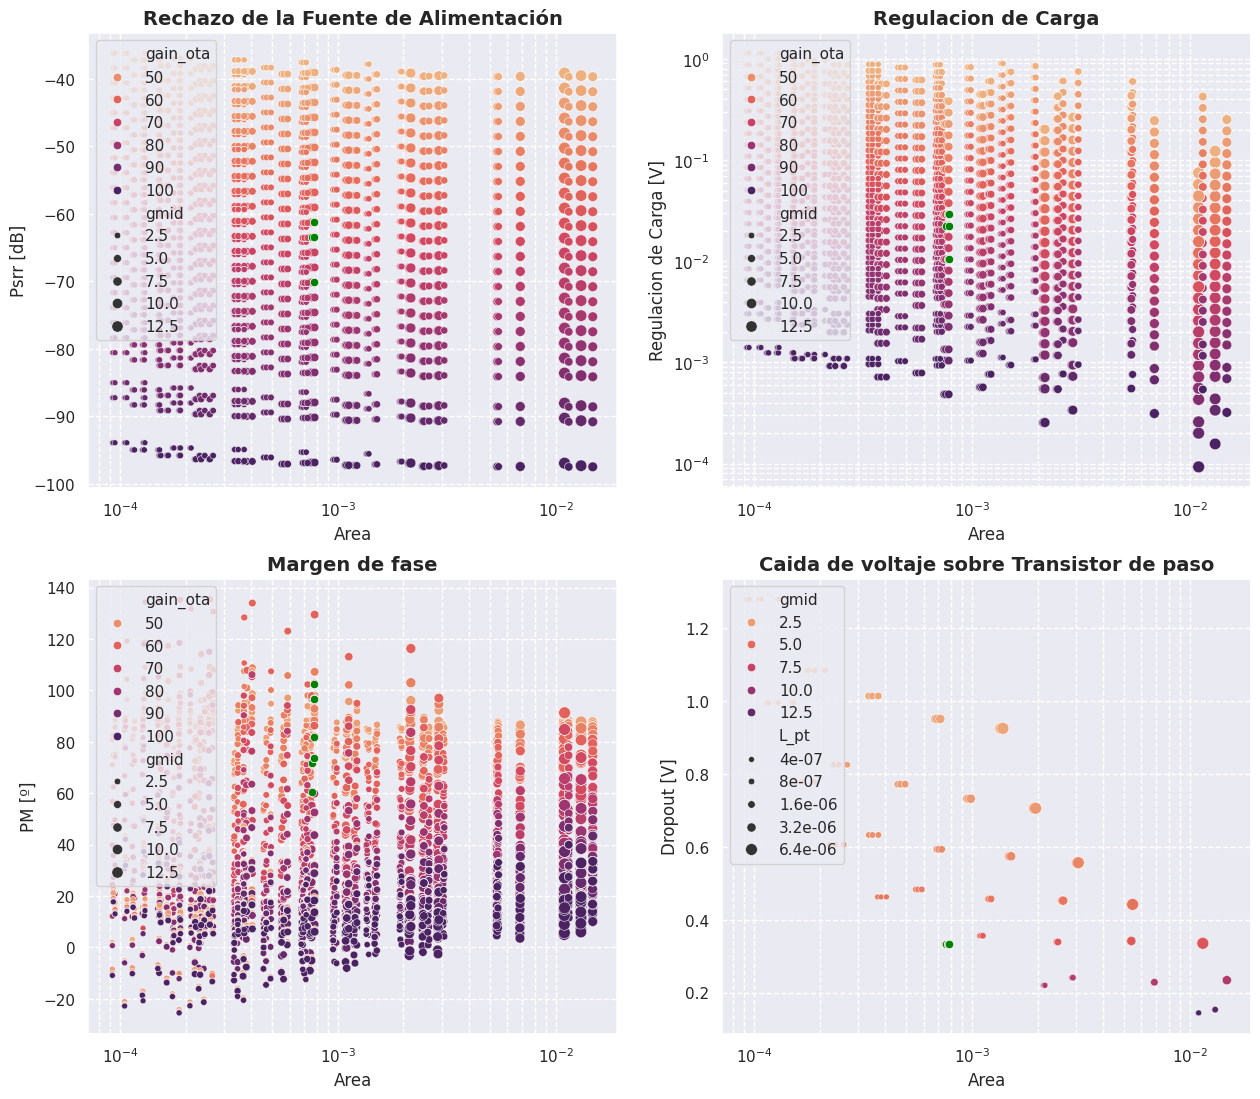

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(15, 13))
sns.scatterplot(ax=axs[0,0], data=ldo_df, x='area', y='psrr', palette='flare', hue='gain_ota', rasterized=True, size='gmid')
sns.scatterplot(ax=axs[0,0], data=ldo_df_new, x='area', y='psrr', c='green')
sns.scatterplot(ax=axs[0,1], data=ldo_df, x='area', y='loadreg', palette='flare', rasterized=True, hue='gain_ota', size='gmid')
sns.scatterplot(ax=axs[0,1], data=ldo_df_new, x='area', y='loadreg', c='green')
sns.scatterplot(ax=axs[1,1], data=ldo_df, x='area', y=('dropout'), palette='flare', hue='gmid', rasterized=True, size=('L_pt'))
sns.scatterplot(ax=axs[1,1], data=ldo_df_new, x='area', y=('dropout'), c='green')
sns.scatterplot(ax=axs[1,0], data=ldo_df, x='area', y="phase_margin_LDO_wc", palette='flare', hue="gain_ota", rasterized=True, size='gmid')
sns.scatterplot(ax=axs[1,0], data=ldo_df_new, x='area', y="phase_margin_LDO_wc", c='green')

axs[0,0].set_title(r"Rechazo de la Fuente de Alimentación", fontsize=14, weight='bold')
axs[0,0].set_xlabel(r"Area")
axs[0,0].set_ylabel(r"Psrr [dB]")
axs[0,0].locator_params(axis='x', nbins=10) 
axs[0,0].legend(loc = 'upper right')

axs[0,1].set_title(r"Regulacion de Carga", fontsize=14, weight='bold')
axs[0,1].set_xlabel(r"Area")
axs[0,1].set_ylabel(r"Regulacion de Carga [V]")
axs[0,1].legend(loc = 'upper right')

axs[1,1].set_xlabel(r"Area")
axs[1,1].set_ylabel(r"Dropout [V]")
axs[1,1].set_title(r"Caida de voltaje sobre Transistor de paso", fontsize=14, weight='bold')
axs[1,1].legend(loc = 'upper right')

axs[1,0].set_title(r"Margen de fase", fontsize=14, weight='bold')
axs[1,0].set_xlabel(r"Area")
axs[1,0].set_ylabel(r"PM [º]")
axs[1,0].legend(loc = 'upper right')
#fig.suptitle(r"Ganancias intrínsecas", fontsize=24, y=1.1)

axs[0,0].set_xscale('log')
axs[0,1].set_xscale('log')
axs[1,0].set_xscale('log')
axs[1,1].set_xscale('log')

axs[0,1].set_yscale('log')



axs[0,0].grid(True,which="both",ls="--")  
axs[0,1].grid(True,which="both",ls="--")  
axs[1,0].grid(True,which="both",ls="--")  
axs[1,1].grid(True,which="both",ls="--")  

sns.move_legend(axs[0,0], "upper left")
sns.move_legend(axs[0,1], "upper left")
sns.move_legend(axs[1,0], "upper left")
sns.move_legend(axs[1,1], "upper left")

plt.savefig('ldo_explore_raw_sky.pdf')

# OTA 1stage

## Case 2

In [25]:
OTA_1stage_macro.ext_mask = None

OTA_1stage_macro.primitives = [diffpair_wc, activeload_wc, currentsource]
OTA_1stage_macro.submacromodels = [] 
OTA_1stage_macro.num_level_exp = -1
OTA_1stage_macro.specifications = [gain_1stage_OTA, rout_1stage_OTA, gm_1stage_OTA]
OTA_1stage_macro.opt_specifications = [gain_1stage_OTA]
OTA_1stage_macro.is_primitive = 0
OTA_1stage_macro.run_pareto = True

_, _, _, ota_1stage_df_wc, mask = dfs(OTA_1stage_macro, debug = False)

############################################
Starting the exploration of:  OTA_1stage_macro
Netlist:  ota_1stage
Running MNA... 
MNA of gain_1stage took: 0.09172844886779785
   net1  vs  vneg  vout  vpos  vdd  vss
0     1   2     3     4     5    6    0
[('vout', 'vpos')]
Netlist:  ota_1stage_rout
Running MNA... 
MNA of rout_1stage took: 0.051309823989868164
   net1  vs  vneg  vout  vpos  vdd  vss  vr
0     1   2     3     4     5    6    0   7
[['vout', 'vr']]
Netlist:  ota_1stage
Running MNA... 
MNA of gm_1stage took: 0.028519392013549805
   net1  vs  vneg  vout  vpos  vdd  vss
0     1   2     3     4     5    6    0
[['vout', 'vpos']]
older order of submacros:  []
new order of submacros:  []
[]
in eval
(-2*Raload_1**2*Rcs*Rdiff_1**2*gaload_1*gdiff_1**2 - 2*Raload_1**2*Rcs*Rdiff_1*gaload_1*gdiff_1 - Raload_1**2*Rdiff_1**2*gaload_1*gdiff_1 - Raload_1**2*Rdiff_1*gdiff_1 - Raload_1*Rcs*Rdiff_1**2*gdiff_1**2 - Raload_1*Rcs*Rdiff_1*gdiff_1 - Raload_1*Rdiff_1**2*gdiff_1)/(2*Raload_1**2*Rcs

## Case 1

In [26]:
OTA_1stage_macro.ext_mask = mask

OTA_1stage_macro.primitives = [diffpair, activeload, currentsource]
OTA_1stage_macro.submacromodels = [] 
OTA_1stage_macro.num_level_exp = -1
OTA_1stage_macro.specifications = [gain_1stage_OTA, rout_1stage_OTA, gm_1stage_OTA]
OTA_1stage_macro.opt_specifications = [gain_1stage_OTA]
OTA_1stage_macro.is_primitive = 0
OTA_1stage_macro.run_pareto = True

ota_1stage_results, ota_1stage_axes, ota_1stage_primouts, ota_1stage_df, _ = dfs(OTA_1stage_macro, debug = False)

############################################
Starting the exploration of:  ota_1stage
Netlist:  ota_1stage
Running MNA... 
MNA of gain_1stage took: 0.050197601318359375
   net1  vs  vneg  vout  vpos  vdd  vss
0     1   2     3     4     5    6    0
[('vout', 'vpos')]
Netlist:  ota_1stage_rout
Running MNA... 
MNA of rout_1stage took: 0.05670499801635742
   net1  vs  vneg  vout  vpos  vdd  vss  vr
0     1   2     3     4     5    6    0   7
[['vout', 'vr']]
Netlist:  ota_1stage
Running MNA... 
MNA of gm_1stage took: 0.025983810424804688
   net1  vs  vneg  vout  vpos  vdd  vss
0     1   2     3     4     5    6    0
[['vout', 'vpos']]
older order of submacros:  []
new order of submacros:  []
[]
in eval
(-2*Raload_1**2*Rcs*Rdiff_1**2*gaload_1*gdiff_1**2 - 2*Raload_1**2*Rcs*Rdiff_1*gaload_1*gdiff_1 - Raload_1**2*Rdiff_1**2*gaload_1*gdiff_1 - Raload_1**2*Rdiff_1*gdiff_1 - Raload_1*Rcs*Rdiff_1**2*gdiff_1**2 - Raload_1*Rcs*Rdiff_1*gdiff_1 - Raload_1*Rdiff_1**2*gdiff_1)/(2*Raload_1**2*Rcs*Rdiff

## Filtering

In [27]:
ota_1stage_df_wc["gain"] = 20*np.log10(ota_1stage_df_wc["gain_1stage"])
ota_1stage_df_wc.sort_values(by=Symbol("W_cs"))

,gdiff_1,Rdiff_1,vs_diff,gaload_1,Raload_1,vout_aload,gcs,Rcs,vs_cs,vgs_cs,...,gm_1stage,W_diff,L_diff,vout_1stage,W_al,L_al,W_cs,L_cs,area,gain
8154,0.000101,1.147164e+06,0.425,0.000083,1.278439e+05,1.471112,0.000031,195734.018570,0.425,1.025,...,0.000096,0.000018,1.600000e-06,1.471112,0.000064,4.000000e-07,1.398493e-07,4.000000e-07,0.000085,20.936727
1904,0.000113,6.575628e+05,0.425,0.000083,1.278439e+05,1.471112,0.000031,195734.018570,0.425,1.025,...,0.000108,0.000015,4.000000e-07,1.471112,0.000064,4.000000e-07,1.398493e-07,4.000000e-07,0.000080,21.311993
761779,0.000092,2.224030e+06,0.425,0.000040,1.054553e+07,1.097752,0.000031,195734.018570,0.425,1.025,...,0.000091,0.000046,6.400000e-06,1.097752,0.000026,6.400000e-06,1.398493e-07,4.000000e-07,0.000085,44.554915
5029,0.000108,8.660769e+05,0.425,0.000083,1.278439e+05,1.471112,0.000031,195734.018570,0.425,1.025,...,0.000103,0.000015,8.000000e-07,1.471112,0.000064,4.000000e-07,1.398493e-07,4.000000e-07,0.000081,21.242372
689154,0.000096,1.590427e+06,0.425,0.000039,1.092843e+07,1.085344,0.000031,195734.018570,0.425,1.025,...,0.000095,0.000027,3.200000e-06,1.085344,0.000026,6.400000e-06,1.398493e-07,4.000000e-07,0.000064,42.504847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689020,0.000054,3.064636e+06,0.300,0.000039,1.092843e+07,1.085344,0.000325,500638.140501,0.300,0.100,...,0.000054,0.000004,3.200000e-06,1.085344,0.000026,6.400000e-06,3.452557e+00,6.400000e-06,3.452603,42.235873
761645,0.000051,4.233649e+06,0.300,0.000040,1.054553e+07,1.097752,0.000325,500638.140501,0.300,0.100,...,0.000051,0.000008,6.400000e-06,1.097752,0.000026,6.400000e-06,3.452557e+00,6.400000e-06,3.452610,43.778559
584645,0.000051,3.915650e+06,0.300,0.000023,1.790544e+07,0.853741,0.000325,500638.140501,0.300,0.100,...,0.000051,0.000008,6.400000e-06,0.853741,0.000007,6.400000e-06,3.452557e+00,6.400000e-06,3.452591,44.351424
673145,0.000051,4.196389e+06,0.300,0.000036,1.197157e+07,1.051456,0.000325,500638.140501,0.300,0.100,...,0.000051,0.000008,6.400000e-06,1.051456,0.000026,6.400000e-06,3.452557e+00,6.400000e-06,3.452610,44.030424


In [28]:
ota_1stage_df["gain"] = 20*np.log10(ota_1stage_df["gain_1stage"])
ota_1stage_df["gain_wc"] = ota_1stage_df_wc["gain"]

ota_1stage_df = ota_1stage_df.dropna()

mask = (ota_1stage_df[Symbol("W_cs")]>5e-6) & (ota_1stage_df[Symbol("W_cs")]<1e-4) & (ota_1stage_df[Symbol("W_al")]<1e-4)
ota_1stage_df_new = ota_1stage_df[mask]


In [29]:
ota_1stage_df_new.to_csv("data/SKY_lv_ota_1stage_case1_98_10_10.csv", index=False)

In [30]:
ota_1stage_df_wc = ota_1stage_df_wc[mask]
ota_1stage_df_wc

,gdiff_1,Rdiff_1,vs_diff,gaload_1,Raload_1,vout_aload,gcs,Rcs,vs_cs,vgs_cs,...,gm_1stage,W_diff,L_diff,vout_1stage,W_al,L_al,W_cs,L_cs,area,gain
1917,0.000113,6.575628e+05,0.425,0.000083,1.278439e+05,1.471112,0.000098,1.326519e+06,0.425,0.625,...,0.000108,0.000015,4.000000e-07,1.471112,0.000064,4.000000e-07,0.000007,0.000003,0.000089,21.304659
1922,0.000113,6.575628e+05,0.425,0.000083,1.278439e+05,1.471112,0.000092,1.752801e+06,0.425,0.625,...,0.000108,0.000015,4.000000e-07,1.471112,0.000064,4.000000e-07,0.000013,0.000006,0.000098,21.304344
5042,0.000108,8.660769e+05,0.425,0.000083,1.278439e+05,1.471112,0.000098,1.326519e+06,0.425,0.625,...,0.000103,0.000015,8.000000e-07,1.471112,0.000064,4.000000e-07,0.000007,0.000003,0.000091,21.234697
5047,0.000108,8.660769e+05,0.425,0.000083,1.278439e+05,1.471112,0.000092,1.752801e+06,0.425,0.625,...,0.000103,0.000015,8.000000e-07,1.471112,0.000064,4.000000e-07,0.000013,0.000006,0.000100,21.234367
8167,0.000101,1.147164e+06,0.425,0.000083,1.278439e+05,1.471112,0.000098,1.326519e+06,0.425,0.625,...,0.000096,0.000018,1.600000e-06,1.471112,0.000064,4.000000e-07,0.000007,0.000003,0.000094,20.928541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761642,0.000051,4.233649e+06,0.300,0.000040,1.054553e+07,1.097752,0.000176,7.457421e+05,0.300,0.500,...,0.000051,0.000008,6.400000e-06,1.097752,0.000026,6.400000e-06,0.000036,0.000003,0.000086,43.778496
761647,0.000051,4.233649e+06,0.300,0.000040,1.054553e+07,1.097752,0.000166,1.000027e+06,0.300,0.500,...,0.000051,0.000008,6.400000e-06,1.097752,0.000026,6.400000e-06,0.000061,0.000006,0.000114,43.778462
761648,0.000051,4.233649e+06,0.300,0.000040,1.054553e+07,1.097752,0.000069,4.815326e+05,0.300,0.700,...,0.000051,0.000008,6.400000e-06,1.097752,0.000026,6.400000e-06,0.000007,0.000006,0.000060,43.778566
761792,0.000092,2.224030e+06,0.425,0.000040,1.054553e+07,1.097752,0.000098,1.326519e+06,0.425,0.625,...,0.000091,0.000046,6.400000e-06,1.097752,0.000026,6.400000e-06,0.000007,0.000003,0.000095,44.554680


In [31]:
ota_1stage_df_wc.to_csv("data/SKY_lv_ota_1stage_case2_98_10_10.csv", index=False)

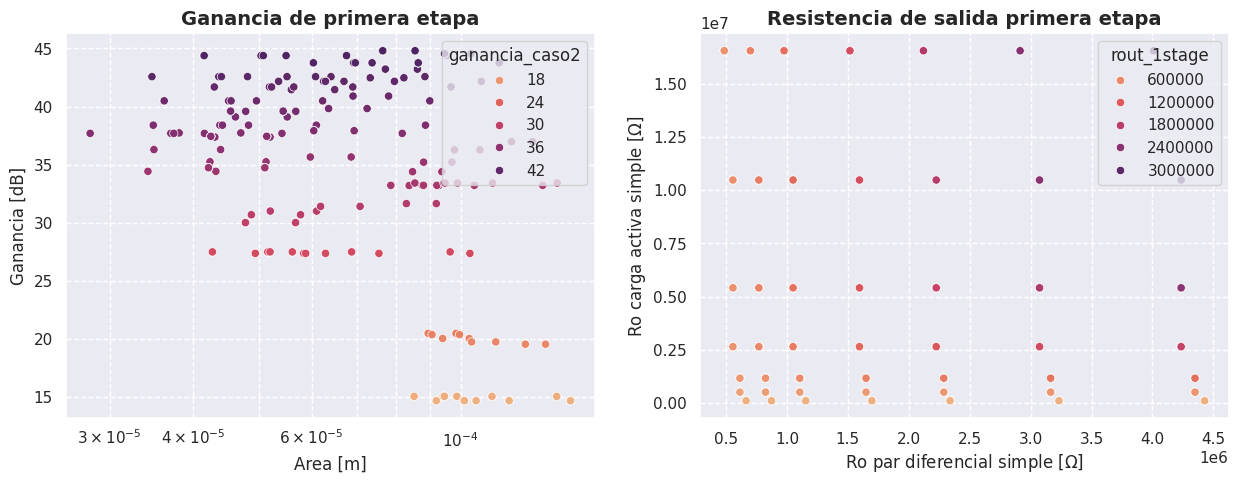

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(ax=axs[0], data=ota_1stage_df_new, x="area", y="gain", hue="gain_wc", palette='flare')
sns.scatterplot(ax=axs[1], data=ota_1stage_df_new, x=Symbol("Rdiff_1"), y=Symbol("Raload_1"), hue="rout_1stage", palette='flare')

axs[0].set_title(r"Ganancia de primera etapa", fontsize=14, weight='bold')
axs[0].set_xlabel(r"Area [m]")
axs[0].set_ylabel(r"Ganancia [dB]")
axs[0].locator_params(axis='x', nbins=10) 
axs[0].legend(loc = 'upper right')

axs[1].set_title(r"Resistencia de salida primera etapa", fontsize=14, weight='bold')
axs[1].set_xlabel(r"Ro par diferencial simple $[\Omega]$")
axs[1].set_ylabel(r"Ro carga activa simple $[\Omega]$")
axs[1].legend(loc = 'upper right')

axs[0].set_xscale('log')

axs[0].grid(True,which="both",ls="--")  
axs[1].grid(True,which="both",ls="--")  

sns.move_legend(axs[1], "upper right",title="rout_1stage")
sns.move_legend(axs[0], "upper right",title="ganancia_caso2")

plt.savefig('ota_1stage_explore.pdf')

# OTA 2stage 

## Case 2

In [33]:
OTA_2stage_macro.ext_mask = None

OTA_2stage_macro.primitives = [stage2_t_wc, stage2_cs_wc]
OTA_2stage_macro.submacromodels = [] 
OTA_2stage_macro.num_level_exp = -1
OTA_2stage_macro.specifications = [gain_2stage_OTA, rout_2stage_OTA, gm_2stage_OTA]
OTA_2stage_macro.opt_specifications = [gain_2stage_OTA]
OTA_2stage_macro.is_primitive = 0
OTA_2stage_macro.run_pareto = True

_, _, _, ota_2stage_df_wc, mask = dfs(OTA_2stage_macro, debug = False)

############################################
Starting the exploration of:  OTA_2stage_macro
Netlist:  ota_2stage_v2
Running MNA... 
MNA of gain_2stage took: 0.06019186973571777
   vdd  vout  vin  vss
0    1     2    3    0
[('vout', 'vin')]
Netlist:  ota_2stage_rout_v2
Running MNA... 
MNA of rout_2stage took: 0.0516362190246582
   vr  vss  vout  vdd  vin
0   1    0     2    3    4
[['vout', 'vr']]
Netlist:  ota_2stage_v2
Running MNA... 
MNA of gm_2stage took: 0.02186274528503418
   vdd  vout  vin  vss
0    1     2    3    0
[['vout', 'vin']]
older order of submacros:  []
new order of submacros:  []
[]
in eval
-Rcs_2stage*Ro_2stage*gm_2stage/(Rcs_2stage + Ro_2stage)
lambdify variables: (gm_2stage, Ro_2stage, Cin_2stage, gcs_2stage, Rcs_2stage, vgs_cs_2stage) <function _lambdifygenerated at 0x7effd689e050>
#### creating the primods_list ####
primmods_outputs_aux:  {W_2stage: array([4.86521080e-07, 1.38777698e-06, 3.11590537e-06, 6.88186557e-06,
       1.46400277e-05, 1.21150318e-06, 4.63

In [34]:
ota_2stage_df_wc["gain"] = 20*np.log10(ota_2stage_df_wc["gain_2stage"])
ota_2stage_df_wc_new = ota_2stage_df_wc[(ota_2stage_df_wc[Symbol("W_2stage")]<3e-4) & (ota_2stage_df_wc[Symbol("W_2stage")]>3e-6) & (ota_2stage_df_wc[Symbol("W_cs_2stage")]<3e-4) & (ota_2stage_df_wc[Symbol("W_cs_2stage")]>3e-6)]
ota_2stage_df_wc_new.sort_values(by=Symbol("W_2stage"))

,gm_2stage,Ro_2stage,Cin_2stage,gcs_2stage,Rcs_2stage,vgs_cs_2stage,gain_2stage,rout_2stage,gm_2stage,W_2stage,L_2stage,vin_2stage,W_cs_2stage,L_cs_2stage,area,gain
52,0.000040,67127.567689,3.136576e-14,0.000213,4.063876e+05,0.500,2.301293,57611.271102,0.000040,0.000003,0.000002,0.867342,0.000022,4.000000e-07,0.000027,7.239439
3027,0.000040,67127.567689,3.136576e-14,0.000051,4.062825e+06,0.800,2.637840,66036.487147,0.000040,0.000003,0.000002,0.867342,0.000004,6.400000e-06,0.000015,8.424969
452,0.000040,67127.567689,3.136576e-14,0.000071,2.348552e+06,0.700,2.606911,65262.208712,0.000040,0.000003,0.000002,0.867342,0.000004,3.200000e-06,0.000012,8.322525
552,0.000040,67127.567689,3.136576e-14,0.000161,1.399002e+06,0.500,2.558653,64054.093254,0.000040,0.000003,0.000002,0.867342,0.000061,6.400000e-06,0.000072,8.160228
2402,0.000040,67127.567689,3.136576e-14,0.000075,2.946020e+06,0.675,2.621686,65632.084973,0.000040,0.000003,0.000002,0.867342,0.000008,6.400000e-06,0.000019,8.371614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,0.000151,735617.503927,2.208998e-12,0.000161,1.399002e+06,0.500,72.739719,482114.138781,0.000151,0.000225,0.000003,1.297777,0.000061,6.400000e-06,0.000296,37.235432
463,0.000151,735617.503927,2.208998e-12,0.000071,2.348552e+06,0.700,84.515384,560162.478420,0.000151,0.000225,0.000003,1.297777,0.000004,3.200000e-06,0.000235,38.538715
2388,0.000151,735617.503927,2.208998e-12,0.000180,1.217187e+06,0.475,69.178692,458511.881027,0.000151,0.000225,0.000003,1.297777,0.000091,6.400000e-06,0.000326,36.799447
63,0.000151,735617.503927,2.208998e-12,0.000213,4.063876e+05,0.500,39.495369,261772.744690,0.000151,0.000225,0.000003,1.297777,0.000022,4.000000e-07,0.000251,31.930924


## Case 1

In [35]:
OTA_2stage_macro.ext_mask = mask

OTA_2stage_macro.primitives = [stage2_t, stage2_cs]
OTA_2stage_macro.submacromodels = [] 
OTA_2stage_macro.num_level_exp = -1
OTA_2stage_macro.specifications = [gain_2stage_OTA, rout_2stage_OTA, gm_2stage_OTA]
OTA_2stage_macro.opt_specifications = [gain_2stage_OTA]
OTA_2stage_macro.is_primitive = 0
OTA_2stage_macro.run_pareto = True

_, _, _, ota_2stage_df, _ = dfs(OTA_2stage_macro, debug = False)

############################################
Starting the exploration of:  ota_2stage_v2
Netlist:  ota_2stage_v2
Running MNA... 
MNA of gain_2stage took: 0.029680490493774414
   vdd  vout  vin  vss
0    1     2    3    0
[('vout', 'vin')]
Netlist:  ota_2stage_rout_v2
Running MNA... 
MNA of rout_2stage took: 0.02632761001586914
   vr  vss  vout  vdd  vin
0   1    0     2    3    4
[['vout', 'vr']]
Netlist:  ota_2stage_v2
Running MNA... 
MNA of gm_2stage took: 0.02260589599609375
   vdd  vout  vin  vss
0    1     2    3    0
[['vout', 'vin']]
older order of submacros:  []
new order of submacros:  []
[]
in eval
-Rcs_2stage*Ro_2stage*gm_2stage/(Rcs_2stage + Ro_2stage)
lambdify variables: (gm_2stage, Ro_2stage, Cin_2stage, gcs_2stage, Rcs_2stage, vgs_cs_2stage) <function _lambdifygenerated at 0x7effd6b6caf0>
#### creating the primods_list ####
primmods_outputs_aux:  {W_2stage: array([4.86521080e-07, 1.38777698e-06, 3.11590537e-06, 6.88186557e-06,
       1.46400277e-05, 1.21150318e-06, 4.630

In [36]:
ota_2stage_df["gain"] = 20*np.log10(ota_2stage_df["gain_2stage"])
ota_2stage_df_new = ota_2stage_df[(ota_2stage_df_wc[Symbol("W_2stage")]<3e-4) & (ota_2stage_df_wc[Symbol("W_2stage")]>3e-6) & (ota_2stage_df_wc[Symbol("W_cs_2stage")]<3e-4) & (ota_2stage_df_wc[Symbol("W_cs_2stage")]>3e-6)]
ota_2stage_df_new

,gm_2stage,Ro_2stage,Cin_2stage,gcs_2stage,Rcs_2stage,vgs_cs_2stage,gain_2stage,rout_2stage,gm_2stage,W_2stage,L_2stage,vin_2stage,W_cs_2stage,L_cs_2stage,area,gain
52,0.000050,1.418006e+06,2.969312e-14,0.000216,3.614087e+05,0.5,14.386936,2.880046e+05,0.000050,0.000003,1.600000e-06,0.9,0.000022,4.000000e-07,0.000027,23.159366
53,0.000050,2.595249e+06,1.385491e-13,0.000216,3.614087e+05,0.5,15.858570,3.172317e+05,0.000050,0.000007,3.200000e-06,0.9,0.000022,4.000000e-07,0.000032,24.005280
54,0.000051,5.124836e+06,6.399718e-13,0.000216,3.614087e+05,0.5,17.215476,3.376007e+05,0.000051,0.000015,6.400000e-06,0.9,0.000022,4.000000e-07,0.000043,24.718381
56,0.000077,5.545358e+05,1.781634e-14,0.000216,3.614087e+05,0.5,16.918111,2.188059e+05,0.000077,0.000005,8.000000e-07,1.1,0.000022,4.000000e-07,0.000028,24.567038
57,0.000082,1.304743e+06,8.370936e-14,0.000216,3.614087e+05,0.5,23.101712,2.830147e+05,0.000082,0.000011,1.600000e-06,1.1,0.000022,4.000000e-07,0.000035,27.272883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035,0.000099,1.499846e+05,7.902724e-15,0.000051,3.903530e+06,0.8,14.366924,1.444350e+05,0.000099,0.000005,4.000000e-07,1.3,0.000004,6.400000e-06,0.000016,23.147276
3036,0.000141,2.875791e+05,8.692485e-14,0.000051,3.903530e+06,0.8,37.829655,2.678465e+05,0.000141,0.000039,8.000000e-07,1.3,0.000004,6.400000e-06,0.000050,31.556647
3037,0.000153,6.357379e+05,4.696648e-13,0.000051,3.903530e+06,0.8,83.641073,5.467009e+05,0.000153,0.000109,1.600000e-06,1.3,0.000004,6.400000e-06,0.000121,38.448392
3038,0.000151,1.359389e+06,2.035330e-12,0.000051,3.903530e+06,0.8,151.935128,1.008265e+06,0.000151,0.000225,3.200000e-06,1.3,0.000004,6.400000e-06,0.000239,43.633164


## filtering

In [37]:
mask = (ota_2stage_df["gain"]>15) & (ota_2stage_df[Symbol("W_2stage")]<1e-4) & (ota_2stage_df[Symbol("W_cs_2stage")]>5e-6) & (ota_2stage_df[Symbol("W_cs_2stage")]<1e-4)
ota_2stage_df_new = ota_2stage_df_new[mask]
ota_2stage_df_wc_new = ota_2stage_df_wc_new[mask]

/tmp/ipykernel_11702/533869183.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ota_2stage_df_new = ota_2stage_df_new[mask]
/tmp/ipykernel_11702/533869183.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ota_2stage_df_wc_new = ota_2stage_df_wc_new[mask]


In [38]:
ota_2stage_df_new["gain_wc"] = ota_2stage_df_wc_new["gain"]
ota_2stage_df_new

/tmp/ipykernel_11702/3031976428.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ota_2stage_df_new["gain_wc"] = ota_2stage_df_wc_new["gain"]


,gm_2stage,Ro_2stage,Cin_2stage,gcs_2stage,Rcs_2stage,vgs_cs_2stage,gain_2stage,rout_2stage,gm_2stage,W_2stage,L_2stage,vin_2stage,W_cs_2stage,L_cs_2stage,area,gain,gain_wc
52,0.000050,1.418006e+06,2.969312e-14,0.000216,3.614087e+05,0.5,14.386936,2.880046e+05,0.000050,0.000003,1.600000e-06,0.9,0.000022,4.000000e-07,0.000027,23.159366,7.239439
53,0.000050,2.595249e+06,1.385491e-13,0.000216,3.614087e+05,0.5,15.858570,3.172317e+05,0.000050,0.000007,3.200000e-06,0.9,0.000022,4.000000e-07,0.000032,24.005280,8.772005
54,0.000051,5.124836e+06,6.399718e-13,0.000216,3.614087e+05,0.5,17.215476,3.376007e+05,0.000051,0.000015,6.400000e-06,0.9,0.000022,4.000000e-07,0.000043,24.718381,10.586221
56,0.000077,5.545358e+05,1.781634e-14,0.000216,3.614087e+05,0.5,16.918111,2.188059e+05,0.000077,0.000005,8.000000e-07,1.1,0.000022,4.000000e-07,0.000028,24.567038,17.622138
57,0.000082,1.304743e+06,8.370936e-14,0.000216,3.614087e+05,0.5,23.101712,2.830147e+05,0.000082,0.000011,1.600000e-06,1.1,0.000022,4.000000e-07,0.000035,27.272883,21.067226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3008,0.000080,2.645694e+06,3.863504e-13,0.000102,2.199513e+06,0.6,95.936598,1.201030e+06,0.000080,0.000024,3.200000e-06,1.1,0.000016,6.400000e-06,0.000050,39.639686,26.611923
3009,0.000081,5.121751e+06,1.754058e-12,0.000102,2.199513e+06,0.6,125.105904,1.538718e+06,0.000081,0.000052,6.400000e-06,1.1,0.000016,6.400000e-06,0.000081,41.945556,30.948448
3010,0.000099,1.499846e+05,7.902724e-15,0.000102,2.199513e+06,0.6,13.966563,1.404101e+05,0.000099,0.000005,4.000000e-07,1.3,0.000016,6.400000e-06,0.000028,22.901791,18.543429
3011,0.000141,2.875791e+05,8.692485e-14,0.000102,2.199513e+06,0.6,35.920179,2.543267e+05,0.000141,0.000039,8.000000e-07,1.3,0.000016,6.400000e-06,0.000062,31.106770,28.150685


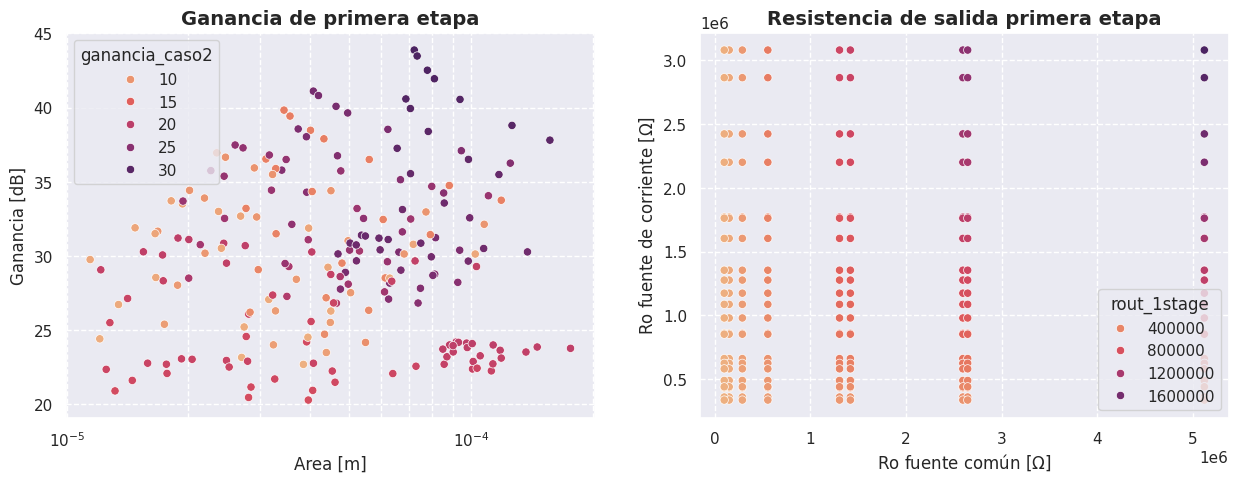

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(ax=axs[0], data=ota_2stage_df_new, x="area", y="gain", palette='flare', hue="gain_wc")
sns.scatterplot(ax=axs[1], data=ota_2stage_df_new, x=Symbol("Ro_2stage"), y=Symbol("Rcs_2stage"), hue="rout_2stage", palette='flare')

axs[0].set_title(r"Ganancia de primera etapa", fontsize=14, weight='bold')
axs[0].set_xlabel(r"Area [m]")
axs[0].set_ylabel(r"Ganancia [dB]")
axs[0].locator_params(axis='x', nbins=10) 
axs[0].legend(loc = 'upper right')

axs[1].set_title(r"Resistencia de salida primera etapa", fontsize=14, weight='bold')
axs[1].set_xlabel(r"Ro fuente común $[\Omega]$")
axs[1].set_ylabel(r"Ro fuente de corriente $[\Omega]$")
axs[1].legend(loc = 'upper right')

axs[0].set_xscale('log')

axs[0].grid(True,which="both",ls="--")  
axs[1].grid(True,which="both",ls="--")  

sns.move_legend(axs[1], "lower right",title="rout_1stage")
sns.move_legend(axs[0], "upper left",title="ganancia_caso2")

plt.savefig('ota_2stage_explore.pdf')

In [40]:
ota_2stage_df_new.to_csv("data/SKY_lv_ota_2stage_case1.csv", index=False)
ota_2stage_df_wc_new.to_csv("data/SKY_lv_ota_2stage_case2.csv", index=False)

# OTA exploration 3

In [41]:
ota_1stage_df_new = pd.read_csv("data/SKY_lv_ota_1stage_case1_98_10_10.csv")
#ota_1stage_df_new = ota_1stage_df_new.sort_values(by="gain").drop_duplicates()
print(len(ota_1stage_df_new))

ota_2stage_df_new = pd.read_csv("data/SKY_lv_ota_2stage_case1.csv")
#mask = (ota_2stage_df_new["Ro_2stage"]>10000) & (ota_2stage_df_new["Ro_2stage"]<1000000)
#ota_2stage_df_new = ota_2stage_df_new[mask]
print(len(ota_2stage_df_new))

770
220


In [42]:
ota_1stage_df_wc_new = pd.read_csv("data/SKY_lv_ota_1stage_case2_98_10_10.csv")
print(len(ota_1stage_df_wc_new))

ota_2stage_df_wc_new = pd.read_csv("data/SKY_lv_ota_2stage_case2.csv")
#ota_2stage_df_wc_new = ota_2stage_df_wc_new[mask]
print(len(ota_2stage_df_wc_new))

770
220


In [43]:
OTA_2stage_primitive_wc = Primitive(parameters={Symbol("Ra_2stage"): ota_2stage_df_wc_new["rout_2stage"].values,
                                  Symbol("gma_2stage"): ota_2stage_df_wc_new["gm_2stage"].values,
                                  Symbol("Cin_2stage"): ota_2stage_df_wc_new["Cin_2stage"].values})

OTA_2stage_primitive_wc.outputs = {
    Symbol("W_2stage"): ota_2stage_df_wc_new["W_2stage"].values,
    Symbol("L_2stage"): ota_2stage_df_wc_new["L_2stage"].values,
    Symbol("vin_2stage"): ota_2stage_df_wc_new["vin_2stage"].values,
    Symbol("W_cs_2stage"): ota_2stage_df_wc_new["W_cs_2stage"].values,
    Symbol("L_cs_2stage"): ota_2stage_df_wc_new["L_cs_2stage"].values,
    Symbol("vgs_cs_2stage"): ota_2stage_df_wc_new["vgs_cs_2stage"].values}

OTA_1stage_primitive_wc = Primitive(parameters={
    Symbol("Ra_1stage"): ota_1stage_df_wc_new["rout_1stage"].values,
    Symbol("gma_1stage"): ota_1stage_df_wc_new["gm_1stage"].values})
OTA_1stage_primitive_wc.outputs = {
    Symbol("W_diff"): ota_1stage_df_wc_new["W_diff"].values,
    Symbol("L_diff"): ota_1stage_df_wc_new["L_diff"].values,
    Symbol("vout_1stage"): ota_1stage_df_wc_new["vout_1stage"].values,
    Symbol("W_al"): ota_1stage_df_wc_new["W_al"].values,
    Symbol("L_al"): ota_1stage_df_wc_new["L_al"].values,
    Symbol("W_cs"): ota_1stage_df_wc_new["W_cs"].values,
    Symbol("L_cs"): ota_1stage_df_wc_new["L_cs"].values,
    Symbol("vgs_cs"): ota_1stage_df_wc_new["vgs_cs"].values}

In [44]:
phase_margin_OTA.parametros = {
    Symbol("V1"): 0,
    Symbol("Vpos"): 1,
    Symbol("Cin_pt"): Cin_pt_wc}

rout_OTA.parametros = {
    Symbol("Vpos"): 0,
    Symbol("Vr"): 1,
    Symbol("s"): 0,
    Symbol("Rr"): 1000,
    Symbol("Cin_pt"): Cin_pt_wc}

OTA_macro.ext_mask = None

OTA_macro.primitives = [OTA_2stage_primitive_wc, OTA_1stage_primitive_wc, Cc_primitive]
OTA_macro.submacromodels = []
OTA_macro.num_level_exp = 1
OTA_macro.specifications = [gain_OTA, rout_OTA, gm_OTA]
OTA_macro.opt_specifications = [gain_OTA]
OTA_macro.is_primitive = 0
OTA_macro.run_pareto = False

_, _, _, ota_df_wc, mask_ota = dfs(OTA_macro, debug = False)

############################################
Starting the exploration of:  OTA_macro
Netlist:  OpAmp_2stage
Running MNA... 
MNA of gain_OTA took: 0.05204439163208008
   net1  vss  vpos  vout  net2
0     1    0     2     3     4
[['vout', 'vpos']]
Netlist:  OpAmp_2stage_rout
Running MNA... 
MNA of rout_OTA took: 0.05311274528503418
   net1  vss  vpos  vout  net2  vr
0     1    0     2     3     4   5
[['vout', 'vr']]
Netlist:  OpAmp_2stage
Running MNA... 
MNA of gm_OTA took: 0.03144502639770508
   net1  vss  vpos  vout  net2
0     1    0     2     3     4
[['vout', 'vpos']]
older order of submacros:  []
new order of submacros:  []
[]
in eval
-Ra_1stage*Ra_2stage*gma_1stage*gma_2stage
lambdify variables: (Ra_2stage, gma_2stage, Cin_2stage, Ra_1stage, gma_1stage, Cc, Rc) <function _lambdifygenerated at 0x7effd413e7a0>
#### creating the primods_list ####
primmods_outputs_aux:  {W_2stage: array([3.11590537e-06, 6.88186557e-06, 1.46400277e-05, 4.63071496e-06,
       1.10737523e-05, 2.4106391

In [45]:
ota_df_wc["gain"] = 20*np.log10(ota_df_wc["gain_OTA"])
ota_df_wc

,Ra_2stage,gma_2stage,Cin_2stage,Ra_1stage,gma_1stage,Cc,Rc,gain_OTA,rout_OTA,gm_OTA,...,L_al,W_cs,L_cs,vgs_cs,W_cc,L_cc,W_rc,L_rc,area,gain
621,58295.056599,0.000167,7.285932e-14,1.079275e+05,0.000108,1.000000e-13,1000.0,113.061628,58295.056599,0.001939,...,4.000000e-07,0.000007,0.000003,0.625,0.000008,0.000008,0.000001,5.000000e-07,0.000196,41.066305
622,58295.056599,0.000167,7.285932e-14,1.079275e+05,0.000108,3.162278e-12,1000.0,113.061628,58295.056599,0.001939,...,4.000000e-07,0.000007,0.000003,0.625,0.000046,0.000046,0.000001,5.000000e-07,0.000271,41.066305
623,58295.056599,0.000167,7.285932e-14,1.079275e+05,0.000108,1.000000e-10,1000.0,113.061628,58295.056599,0.001939,...,4.000000e-07,0.000007,0.000003,0.625,0.000258,0.000258,0.000001,5.000000e-07,0.000696,41.066305
624,58295.056599,0.000167,7.285932e-14,1.079275e+05,0.000108,1.000000e-13,10000.0,113.061628,58295.056599,0.001939,...,4.000000e-07,0.000007,0.000003,0.625,0.000008,0.000008,0.000004,5.000000e-07,0.000199,41.066305
625,58295.056599,0.000167,7.285932e-14,1.079275e+05,0.000108,3.162278e-12,10000.0,113.061628,58295.056599,0.001939,...,4.000000e-07,0.000007,0.000003,0.625,0.000046,0.000046,0.000004,5.000000e-07,0.000274,41.066305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523308,449109.245285,0.000080,1.852635e-12,1.846847e+06,0.000091,3.162278e-12,10000.0,6067.450489,449109.245285,0.013510,...,6.400000e-06,0.000013,0.000006,0.625,0.000046,0.000046,0.000004,5.000000e-07,0.000278,75.660125
1523309,449109.245285,0.000080,1.852635e-12,1.846847e+06,0.000091,1.000000e-10,10000.0,6067.450489,449109.245285,0.013510,...,6.400000e-06,0.000013,0.000006,0.625,0.000258,0.000258,0.000004,5.000000e-07,0.000702,75.660125
1523310,449109.245285,0.000080,1.852635e-12,1.846847e+06,0.000091,1.000000e-13,100000.0,6067.450489,449109.245285,0.013510,...,6.400000e-06,0.000013,0.000006,0.625,0.000008,0.000008,0.000012,5.000000e-07,0.000210,75.660125
1523311,449109.245285,0.000080,1.852635e-12,1.846847e+06,0.000091,3.162278e-12,100000.0,6067.450489,449109.245285,0.013510,...,6.400000e-06,0.000013,0.000006,0.625,0.000046,0.000046,0.000012,5.000000e-07,0.000286,75.660125


In [46]:
OTA_2stage_primitive = Primitive(parameters={Symbol("Ra_2stage"): ota_2stage_df_new["rout_2stage"].values,
                                  Symbol("gma_2stage"): ota_2stage_df_new["gm_2stage"].values,
                                  Symbol("Cin_2stage"): ota_2stage_df_new["Cin_2stage"].values})

OTA_2stage_primitive.outputs = {
    Symbol("W_2stage"): ota_2stage_df_new["W_2stage"].values,
    Symbol("L_2stage"): ota_2stage_df_new["L_2stage"].values,
    Symbol("vin_2stage"): ota_2stage_df_new["vin_2stage"].values,
    Symbol("W_cs_2stage"): ota_2stage_df_new["W_cs_2stage"].values,
    Symbol("L_cs_2stage"): ota_2stage_df_new["L_cs_2stage"].values,
    Symbol("vgs_cs_2stage"): ota_2stage_df_new["vgs_cs_2stage"].values}

OTA_1stage_primitive = Primitive(parameters={
    Symbol("Ra_1stage"): ota_1stage_df_new["rout_1stage"].values,
    Symbol("gma_1stage"): ota_1stage_df_new["gm_1stage"].values})
OTA_1stage_primitive.outputs = {
    Symbol("W_diff"): ota_1stage_df_new["W_diff"].values,
    Symbol("L_diff"): ota_1stage_df_new["L_diff"].values,
    Symbol("vout_1stage"): ota_1stage_df_new["vout_1stage"].values,
    Symbol("W_al"): ota_1stage_df_new["W_al"].values,
    Symbol("L_al"): ota_1stage_df_new["L_al"].values,
    Symbol("W_cs"): ota_1stage_df_new["W_cs"].values,
    Symbol("L_cs"): ota_1stage_df_new["L_cs"].values,
    Symbol("vgs_cs"): ota_1stage_df_new["vgs_cs"].values}

In [47]:
phase_margin_OTA.parametros = {
    Symbol("V1"): 0,
    Symbol("Vpos"): 1,
    Symbol("Cin_pt"): Cin_pt}

rout_OTA.parametros = {
    Symbol("Vpos"): 0,
    Symbol("Vr"): 1,
    Symbol("s"): 0,
    Symbol("Rr"): 1000,
    Symbol("Cin_pt"): Cin_pt}

OTA_macro.ext_mask = mask_ota

OTA_macro.primitives = [OTA_2stage_primitive, OTA_1stage_primitive, Cc_primitive]
OTA_macro.submacromodels = []
OTA_macro.num_level_exp = 1
OTA_macro.specifications = [gain_OTA, rout_OTA, gm_OTA]
OTA_macro.opt_specifications = [gain_OTA]
OTA_macro.is_primitive = 0
OTA_macro.run_pareto = False

_, _, _, ota_df, _ = dfs(OTA_macro, debug = False)

############################################
Starting the exploration of:  OpAmp_2stage
Netlist:  OpAmp_2stage
Running MNA... 
MNA of gain_OTA took: 0.023075580596923828
   net1  vss  vpos  vout  net2
0     1    0     2     3     4
[['vout', 'vpos']]
Netlist:  OpAmp_2stage_rout
Running MNA... 
MNA of rout_OTA took: 0.02661752700805664
   net1  vss  vpos  vout  net2  vr
0     1    0     2     3     4   5
[['vout', 'vr']]
Netlist:  OpAmp_2stage
Running MNA... 
MNA of gm_OTA took: 0.03006577491760254
   net1  vss  vpos  vout  net2
0     1    0     2     3     4
[['vout', 'vpos']]
older order of submacros:  []
new order of submacros:  []
[]
in eval
-Ra_1stage*Ra_2stage*gma_1stage*gma_2stage
lambdify variables: (Ra_2stage, gma_2stage, Cin_2stage, Ra_1stage, gma_1stage, Cc, Rc) <function _lambdifygenerated at 0x7effd413f130>
#### creating the primods_list ####
primmods_outputs_aux:  {W_2stage: array([3.11590537e-06, 6.88186557e-06, 1.46400277e-05, 4.63071496e-06,
       1.10737523e-05, 2.410

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219], [0, 1, 

In [48]:
ota_df["gain"] = 20*np.log10(ota_df["gain_OTA"])
ota_df

,Ra_2stage,gma_2stage,Cin_2stage,Ra_1stage,gma_1stage,Cc,Rc,gain_OTA,rout_OTA,gm_OTA,...,L_al,W_cs,L_cs,vgs_cs,W_cc,L_cc,W_rc,L_rc,area,gain
621,9.309395e+04,0.000170,6.979471e-14,9.833847e+04,0.000107,1.000000e-13,1000.0,167.400022,9.309395e+04,0.001798,...,4.000000e-07,0.000007,0.000003,0.625,0.000008,0.000008,0.000001,5.000000e-07,0.000196,44.475110
622,9.309395e+04,0.000170,6.979471e-14,9.833847e+04,0.000107,3.162278e-12,1000.0,167.400022,9.309395e+04,0.001798,...,4.000000e-07,0.000007,0.000003,0.625,0.000046,0.000046,0.000001,5.000000e-07,0.000271,44.475110
623,9.309395e+04,0.000170,6.979471e-14,9.833847e+04,0.000107,1.000000e-10,1000.0,167.400022,9.309395e+04,0.001798,...,4.000000e-07,0.000007,0.000003,0.625,0.000258,0.000258,0.000001,5.000000e-07,0.000696,44.475110
624,9.309395e+04,0.000170,6.979471e-14,9.833847e+04,0.000107,1.000000e-13,10000.0,167.400022,9.309395e+04,0.001798,...,4.000000e-07,0.000007,0.000003,0.625,0.000008,0.000008,0.000004,5.000000e-07,0.000199,44.475110
625,9.309395e+04,0.000170,6.979471e-14,9.833847e+04,0.000107,3.162278e-12,10000.0,167.400022,9.309395e+04,0.001798,...,4.000000e-07,0.000007,0.000003,0.625,0.000046,0.000046,0.000004,5.000000e-07,0.000274,44.475110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523308,1.644095e+06,0.000081,1.754058e-12,1.845504e+06,0.000091,3.162278e-12,10000.0,22565.828502,1.644095e+06,0.013725,...,6.400000e-06,0.000013,0.000006,0.625,0.000046,0.000046,0.000004,5.000000e-07,0.000278,87.069026
1523309,1.644095e+06,0.000081,1.754058e-12,1.845504e+06,0.000091,1.000000e-10,10000.0,22565.828502,1.644095e+06,0.013725,...,6.400000e-06,0.000013,0.000006,0.625,0.000258,0.000258,0.000004,5.000000e-07,0.000702,87.069026
1523310,1.644095e+06,0.000081,1.754058e-12,1.845504e+06,0.000091,1.000000e-13,100000.0,22565.828502,1.644095e+06,0.013725,...,6.400000e-06,0.000013,0.000006,0.625,0.000008,0.000008,0.000012,5.000000e-07,0.000210,87.069026
1523311,1.644095e+06,0.000081,1.754058e-12,1.845504e+06,0.000091,3.162278e-12,100000.0,22565.828502,1.644095e+06,0.013725,...,6.400000e-06,0.000013,0.000006,0.625,0.000046,0.000046,0.000012,5.000000e-07,0.000286,87.069026


In [49]:
ota_df["gain"] = 20*np.log10(ota_df["gain_OTA"])
ota_df["gain_wc"] = 20*np.log10(ota_df_wc["gain_OTA"])
ota_df = ota_df.dropna()
ota_df

,Ra_2stage,gma_2stage,Cin_2stage,Ra_1stage,gma_1stage,Cc,Rc,gain_OTA,rout_OTA,gm_OTA,...,W_cs,L_cs,vgs_cs,W_cc,L_cc,W_rc,L_rc,area,gain,gain_wc
621,9.309395e+04,0.000170,6.979471e-14,9.833847e+04,0.000107,1.000000e-13,1000.0,167.400022,9.309395e+04,0.001798,...,0.000007,0.000003,0.625,0.000008,0.000008,0.000001,5.000000e-07,0.000196,44.475110,41.066305
622,9.309395e+04,0.000170,6.979471e-14,9.833847e+04,0.000107,3.162278e-12,1000.0,167.400022,9.309395e+04,0.001798,...,0.000007,0.000003,0.625,0.000046,0.000046,0.000001,5.000000e-07,0.000271,44.475110,41.066305
623,9.309395e+04,0.000170,6.979471e-14,9.833847e+04,0.000107,1.000000e-10,1000.0,167.400022,9.309395e+04,0.001798,...,0.000007,0.000003,0.625,0.000258,0.000258,0.000001,5.000000e-07,0.000696,44.475110,41.066305
624,9.309395e+04,0.000170,6.979471e-14,9.833847e+04,0.000107,1.000000e-13,10000.0,167.400022,9.309395e+04,0.001798,...,0.000007,0.000003,0.625,0.000008,0.000008,0.000004,5.000000e-07,0.000199,44.475110,41.066305
625,9.309395e+04,0.000170,6.979471e-14,9.833847e+04,0.000107,3.162278e-12,10000.0,167.400022,9.309395e+04,0.001798,...,0.000007,0.000003,0.625,0.000046,0.000046,0.000004,5.000000e-07,0.000274,44.475110,41.066305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523308,1.644095e+06,0.000081,1.754058e-12,1.845504e+06,0.000091,3.162278e-12,10000.0,22565.828502,1.644095e+06,0.013725,...,0.000013,0.000006,0.625,0.000046,0.000046,0.000004,5.000000e-07,0.000278,87.069026,75.660125
1523309,1.644095e+06,0.000081,1.754058e-12,1.845504e+06,0.000091,1.000000e-10,10000.0,22565.828502,1.644095e+06,0.013725,...,0.000013,0.000006,0.625,0.000258,0.000258,0.000004,5.000000e-07,0.000702,87.069026,75.660125
1523310,1.644095e+06,0.000081,1.754058e-12,1.845504e+06,0.000091,1.000000e-13,100000.0,22565.828502,1.644095e+06,0.013725,...,0.000013,0.000006,0.625,0.000008,0.000008,0.000012,5.000000e-07,0.000210,87.069026,75.660125
1523311,1.644095e+06,0.000081,1.754058e-12,1.845504e+06,0.000091,3.162278e-12,100000.0,22565.828502,1.644095e+06,0.013725,...,0.000013,0.000006,0.625,0.000046,0.000046,0.000012,5.000000e-07,0.000286,87.069026,75.660125


In [50]:
ota_df_wc["gain"] = 20*np.log10(ota_df_wc["gain_OTA"])
ota_df_wc

,Ra_2stage,gma_2stage,Cin_2stage,Ra_1stage,gma_1stage,Cc,Rc,gain_OTA,rout_OTA,gm_OTA,...,L_al,W_cs,L_cs,vgs_cs,W_cc,L_cc,W_rc,L_rc,area,gain
621,58295.056599,0.000167,7.285932e-14,1.079275e+05,0.000108,1.000000e-13,1000.0,113.061628,58295.056599,0.001939,...,4.000000e-07,0.000007,0.000003,0.625,0.000008,0.000008,0.000001,5.000000e-07,0.000196,41.066305
622,58295.056599,0.000167,7.285932e-14,1.079275e+05,0.000108,3.162278e-12,1000.0,113.061628,58295.056599,0.001939,...,4.000000e-07,0.000007,0.000003,0.625,0.000046,0.000046,0.000001,5.000000e-07,0.000271,41.066305
623,58295.056599,0.000167,7.285932e-14,1.079275e+05,0.000108,1.000000e-10,1000.0,113.061628,58295.056599,0.001939,...,4.000000e-07,0.000007,0.000003,0.625,0.000258,0.000258,0.000001,5.000000e-07,0.000696,41.066305
624,58295.056599,0.000167,7.285932e-14,1.079275e+05,0.000108,1.000000e-13,10000.0,113.061628,58295.056599,0.001939,...,4.000000e-07,0.000007,0.000003,0.625,0.000008,0.000008,0.000004,5.000000e-07,0.000199,41.066305
625,58295.056599,0.000167,7.285932e-14,1.079275e+05,0.000108,3.162278e-12,10000.0,113.061628,58295.056599,0.001939,...,4.000000e-07,0.000007,0.000003,0.625,0.000046,0.000046,0.000004,5.000000e-07,0.000274,41.066305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523308,449109.245285,0.000080,1.852635e-12,1.846847e+06,0.000091,3.162278e-12,10000.0,6067.450489,449109.245285,0.013510,...,6.400000e-06,0.000013,0.000006,0.625,0.000046,0.000046,0.000004,5.000000e-07,0.000278,75.660125
1523309,449109.245285,0.000080,1.852635e-12,1.846847e+06,0.000091,1.000000e-10,10000.0,6067.450489,449109.245285,0.013510,...,6.400000e-06,0.000013,0.000006,0.625,0.000258,0.000258,0.000004,5.000000e-07,0.000702,75.660125
1523310,449109.245285,0.000080,1.852635e-12,1.846847e+06,0.000091,1.000000e-13,100000.0,6067.450489,449109.245285,0.013510,...,6.400000e-06,0.000013,0.000006,0.625,0.000008,0.000008,0.000012,5.000000e-07,0.000210,75.660125
1523311,449109.245285,0.000080,1.852635e-12,1.846847e+06,0.000091,3.162278e-12,100000.0,6067.450489,449109.245285,0.013510,...,6.400000e-06,0.000013,0.000006,0.625,0.000046,0.000046,0.000012,5.000000e-07,0.000286,75.660125


In [51]:
mask = ota_df["gain"]>64.44
ota_df = ota_df[mask]
ota_df_wc = ota_df_wc[mask]

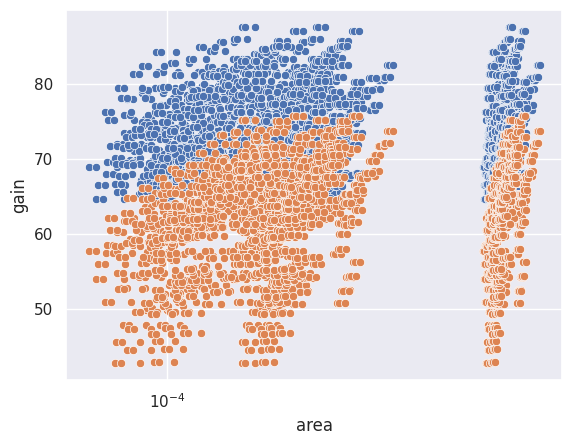

In [52]:
sns.scatterplot(data=ota_df, x="area", y="gain")
sns.scatterplot(data=ota_df_wc, x="area", y="gain")
plt.xscale("log")

In [53]:
ota_df["gain"] = 20*np.log10(ota_df["gain_OTA"])
ota_df["gain_wc"] = 20*np.log10(ota_df_wc["gain_OTA"])

ota_df["gain_1stage"] = 20*np.log10(ota_df[Symbol("Ra_1stage")]*ota_df[Symbol("gma_1stage")])
ota_df["gain_2stage"] = 20*np.log10(ota_df[Symbol("Ra_2stage")]*ota_df[Symbol("gma_2stage")])
ota_df["bw"] = 1/(2*np.pi*ota_df[Symbol("Ra_1stage")]*(ota_df[Symbol("Cin_2stage")]+ota_df[Symbol("gma_2stage")]*ota_df[Symbol("Ra_2stage")]*ota_df[Symbol("Cc")]))

ota_df["bw_2"] = 1/(2*np.pi*ota_df[Symbol("Ra_1stage")]*Cin_pt)

ota_df["bw_wc"] = 1/(2*np.pi*ota_df_wc[Symbol("Ra_1stage")]*(ota_df_wc[Symbol("Cin_2stage")]+ota_df_wc[Symbol("gma_2stage")]*ota_df_wc[Symbol("Ra_2stage")]*ota_df_wc[Symbol("Cc")]))

#ota_df["phase_margin_OTA_wc"] = ota_df_wc["phase_margin_OTA"]

ota_df_wc["gain"] =  20*np.log10(ota_df_wc["gain_OTA"])

ota_df_new = ota_df[((ota_df["bw"]>500) & (ota_df["bw"]<1000) & (ota_df["gain"]>64.44)) | ((ota_df["bw"]>100) & (ota_df["bw"]<1000) & (ota_df["gain"]>73.33))]
ota_df_wc_new = ota_df_wc[((ota_df["bw"]>500) & (ota_df["bw"]<1000) & (ota_df["gain"]>64.44)) | ((ota_df["bw"]>100) & (ota_df["bw"]<1000) & (ota_df["gain"]>73.33))]

ota_df_new.sort_values(by="gain")

/tmp/ipykernel_11702/838698729.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ota_df["gain"] = 20*np.log10(ota_df["gain_OTA"])
/tmp/ipykernel_11702/838698729.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ota_df["gain_wc"] = 20*np.log10(ota_df_wc["gain_OTA"])
/tmp/ipykernel_11702/838698729.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

,Ra_2stage,gma_2stage,Cin_2stage,Ra_1stage,gma_1stage,Cc,Rc,gain_OTA,rout_OTA,gm_OTA,...,W_rc,L_rc,area,gain,gain_wc,gain_1stage,gain_2stage,bw,bw_2,bw_wc
1378114,2.188059e+05,0.000077,1.781634e-14,3.024345e+06,0.000051,3.162278e-12,100000.0,2609.580649,2.188059e+05,0.011926,...,0.000012,5.000000e-07,0.000202,68.331414,61.476346,43.764377,24.567038,983.314274,3813.376937,2164.238720
1378108,2.188059e+05,0.000077,1.781634e-14,3.024345e+06,0.000051,3.162278e-12,1000.0,2609.580649,2.188059e+05,0.011926,...,0.000001,5.000000e-07,0.000191,68.331414,61.476346,43.764377,24.567038,983.314274,3813.376937,2164.238720
1378111,2.188059e+05,0.000077,1.781634e-14,3.024345e+06,0.000051,3.162278e-12,10000.0,2609.580649,2.188059e+05,0.011926,...,0.000004,5.000000e-07,0.000193,68.331414,61.476346,43.764377,24.567038,983.314274,3813.376937,2164.238720
1247416,3.172317e+05,0.000050,1.385491e-13,3.242619e+06,0.000051,3.162278e-12,100000.0,2627.072519,3.172317e+05,0.008281,...,0.000012,5.000000e-07,0.000187,68.389441,53.149111,44.384161,24.005280,976.027351,3556.682529,5569.383612
1247413,3.172317e+05,0.000050,1.385491e-13,3.242619e+06,0.000051,3.162278e-12,10000.0,2627.072519,3.172317e+05,0.008281,...,0.000004,5.000000e-07,0.000179,68.389441,53.149111,44.384161,24.005280,976.027351,3556.682529,5569.383612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523311,1.644095e+06,0.000081,1.754058e-12,1.845504e+06,0.000091,3.162278e-12,100000.0,22565.828502,1.644095e+06,0.013725,...,0.000012,5.000000e-07,0.000286,87.069026,75.660125,44.548112,42.520914,203.170733,6249.224743,746.602208
1523305,1.644095e+06,0.000081,1.754058e-12,1.845504e+06,0.000091,3.162278e-12,1000.0,22565.828502,1.644095e+06,0.013725,...,0.000001,5.000000e-07,0.000275,87.069026,75.660125,44.548112,42.520914,203.170733,6249.224743,746.602208
1519171,1.922553e+06,0.000081,1.754058e-12,3.024564e+06,0.000051,3.162278e-12,100000.0,24110.335803,1.922553e+06,0.012541,...,0.000012,5.000000e-07,0.000237,87.644065,75.229005,43.764121,43.879944,106.077130,3813.100398,437.692903
1519165,1.922553e+06,0.000081,1.754058e-12,3.024564e+06,0.000051,3.162278e-12,1000.0,24110.335803,1.922553e+06,0.012541,...,0.000001,5.000000e-07,0.000226,87.644065,75.229005,43.764121,43.879944,106.077130,3813.100398,437.692903


/tmp/ipykernel_11702/4168062300.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(loc = 'upper right')


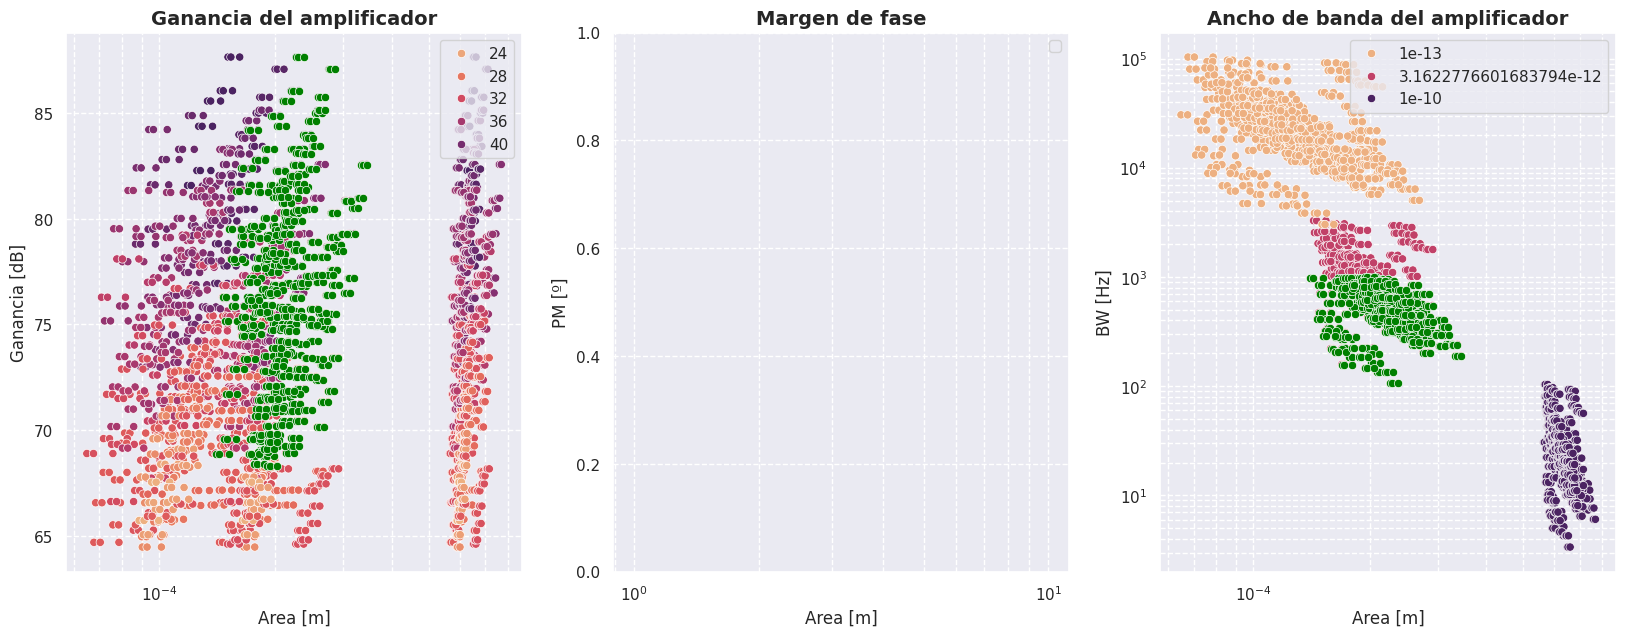

In [54]:
fig, axs = plt.subplots(1, 3, figsize=(20, 7))
sns.scatterplot(ax=axs[0], data=ota_df, x='area', y='gain', palette='flare', hue="gain_2stage")
sns.scatterplot(ax=axs[0], data=ota_df_new, x='area', y='gain', color="green")
#sns.scatterplot(ax=axs[1], data=ota_df, x="area", y="phase_margin_OTA", hue="phase_margin_OTA_wc", palette='flare')
#sns.scatterplot(ax=axs[1], data=ota_df_new, x="area", y="phase_margin_OTA", color="green")
sns.scatterplot(ax=axs[2], data=ota_df, x="area", y="bw", hue=Symbol("Cc"), hue_norm=LogNorm(), palette='flare')
sns.scatterplot(ax=axs[2], data=ota_df_new, x="area", y="bw", color="green")

axs[0].set_title(r"Ganancia del amplificador", fontsize=14, weight='bold')
axs[0].set_xlabel(r"Area [m]")
axs[0].set_ylabel(r"Ganancia [dB]")
axs[0].locator_params(axis='x', nbins=10) 
axs[0].legend(loc = 'upper right')

axs[1].set_title(r"Margen de fase", fontsize=14, weight='bold')
axs[1].set_xlabel(r"Area [m]")
axs[1].set_ylabel(r"PM [º]")
axs[1].legend(loc = 'upper right')

axs[2].set_xlabel(r"Area [m]")
axs[2].set_ylabel(r"BW [Hz]")
axs[2].set_title(r"Ancho de banda del amplificador", fontsize=14, weight='bold')
axs[2].legend(loc = 'upper right')

axs[0].grid(True,which="both",ls="--")  
axs[1].grid(True,which="both",ls="--")  
axs[2].grid(True,which="both",ls="--")  

axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[2].set_xscale('log')

axs[2].set_yscale('log')

#sns.move_legend(axs[0], "upper left",title="ganancia segunda etapa")

plt.savefig('ota_explore_raw_3.svg', dpi=120)

In [55]:
ota_df_new.to_csv("data/SKY_lv_ota_exploration3_case1_98_10_10.csv")
ota_df_wc_new.to_csv("data/SKY_lv_ota_exploration3_case2_98_10_10.csv")

In [56]:
OTA_2stage_primitive_wc = Primitive(parameters={Symbol("Ra_2stage"): ota_df_wc[Symbol("Ra_2stage")].values,
                                  Symbol("gma_2stage"): ota_df_wc[Symbol("gma_2stage")].values,
                                  Symbol("Cin_2stage"): ota_df_wc[Symbol("Cin_2stage")].values,

                                  Symbol("Ra_1stage"): ota_df_wc[Symbol("Ra_1stage")].values,
                                  Symbol("gma_1stage"): ota_df_wc[Symbol("gma_1stage")].values,

                                  Symbol("Cc"): ota_df_wc[Symbol("Cc")].values,
                                  Symbol("Rc"): ota_df_wc[Symbol("Rc")].values,})

OTA_2stage_primitive_wc.outputs = {
    Symbol("W_2stage"): ota_df_wc[Symbol("W_2stage")].values,
    Symbol("L_2stage"): ota_df_wc[Symbol("L_2stage")].values,
    Symbol("vin_2stage"): ota_df_wc[Symbol("vin_2stage")].values,
    Symbol("W_cs_2stage"): ota_df_wc[Symbol("W_cs_2stage")].values,
    Symbol("L_cs_2stage"): ota_df_wc[Symbol("L_cs_2stage")].values,
    Symbol("vgs_cs_2stage"): ota_df_wc[Symbol("vgs_cs_2stage")].values,
    
    Symbol("W_diff"): ota_df_wc[Symbol("W_diff")].values,
    Symbol("L_diff"): ota_df_wc[Symbol("L_diff")].values,
    Symbol("vout_1stage"): ota_df_wc[Symbol("vout_1stage")].values,
    Symbol("W_al"): ota_df_wc[Symbol("W_al")].values,
    Symbol("L_al"): ota_df_wc[Symbol("L_al")].values,
    Symbol("W_cs"): ota_df_wc[Symbol("W_cs")].values,
    Symbol("L_cs"): ota_df_wc[Symbol("L_cs")].values,
    Symbol("vgs_cs"): ota_df_wc[Symbol("vgs_cs")].values,
    
    Symbol("W_cc"): ota_df_wc[Symbol("W_cc")].values,
    Symbol("L_cc"): ota_df_wc[Symbol("L_cc")].values,
    
    Symbol("W_rc"): ota_df_wc[Symbol("W_rc")].values,
    Symbol("L_rc"): ota_df_wc[Symbol("L_rc")].values}

In [57]:
phase_margin_OTA.parametros = {
    Symbol("V1"): 0,
    Symbol("Vpos"): 1,
    Symbol("Cin_pt"): Cin_pt_wc}    

OTA_macro.ext_mask = None

OTA_macro.primitives = [OTA_2stage_primitive_wc]
OTA_macro.submacromodels = []
OTA_macro.num_level_exp = 1
OTA_macro.specifications = [gain_OTA, rout_OTA, gm_OTA, phase_margin_OTA]
OTA_macro.opt_specifications = [gain_OTA]
OTA_macro.is_primitive = 0
OTA_macro.run_pareto = False

_, _, _, ota_df_wc, mask_ota = dfs(OTA_macro, debug = False)

############################################
Starting the exploration of:  OpAmp_2stage
Netlist:  OpAmp_2stage
Running MNA... 
MNA of gain_OTA took: 0.029902219772338867
   net1  vss  vpos  vout  net2
0     1    0     2     3     4
[['vout', 'vpos']]
Netlist:  OpAmp_2stage_rout
Running MNA... 
MNA of rout_OTA took: 0.024984121322631836
   net1  vss  vpos  vout  net2  vr
0     1    0     2     3     4   5
[['vout', 'vr']]
Netlist:  OpAmp_2stage
Running MNA... 
MNA of gm_OTA took: 0.029978513717651367
   net1  vss  vpos  vout  net2
0     1    0     2     3     4
[['vout', 'vpos']]
Netlist:  OpAmp_2stage
Running MNA... 
MNA of phase_margin_OTA took: 0.029166698455810547
   net1  vss  vpos  vout  net2
0     1    0     2     3     4
[['vout', 'vpos']]
older order of submacros:  []
new order of submacros:  []
[]
in eval
-Ra_1stage*Ra_2stage*gma_1stage*gma_2stage
lambdify variables: (Ra_2stage, gma_2stage, Cin_2stage, Ra_1stage, gma_1stage, Cc, Rc) <function _lambdifygenerated at 0x7effcdb6b4

In [58]:
OTA_2stage_primitive = Primitive(parameters={Symbol("Ra_2stage"): ota_df[Symbol("Ra_2stage")].values,
                                  Symbol("gma_2stage"): ota_df[Symbol("gma_2stage")].values,
                                  Symbol("Cin_2stage"): ota_df[Symbol("Cin_2stage")].values,

                                  Symbol("Ra_1stage"): ota_df[Symbol("Ra_1stage")].values,
                                  Symbol("gma_1stage"): ota_df[Symbol("gma_1stage")].values,

                                  Symbol("Cc"): ota_df[Symbol("Cc")].values,
                                  Symbol("Rc"): ota_df[Symbol("Rc")].values,})
OTA_2stage_primitive.outputs = {
    Symbol("W_2stage"): ota_df[Symbol("W_2stage")].values,
    Symbol("L_2stage"): ota_df[Symbol("L_2stage")].values,
    Symbol("vin_2stage"): ota_df[Symbol("vin_2stage")].values,
    Symbol("W_cs_2stage"): ota_df[Symbol("W_cs_2stage")].values,
    Symbol("L_cs_2stage"): ota_df[Symbol("L_cs_2stage")].values,
    Symbol("vgs_cs_2stage"): ota_df[Symbol("vgs_cs_2stage")].values,
    
    Symbol("W_diff"): ota_df[Symbol("W_diff")].values,
    Symbol("L_diff"): ota_df[Symbol("L_diff")].values,
    Symbol("vout_1stage"): ota_df[Symbol("vout_1stage")].values,
    Symbol("W_al"): ota_df[Symbol("W_al")].values,
    Symbol("L_al"): ota_df[Symbol("L_al")].values,
    Symbol("W_cs"): ota_df[Symbol("W_cs")].values,
    Symbol("L_cs"): ota_df[Symbol("L_cs")].values,
    Symbol("vgs_cs"): ota_df[Symbol("vgs_cs")].values,
    
    Symbol("W_cc"): ota_df[Symbol("W_cc")].values,
    Symbol("L_cc"): ota_df[Symbol("L_cc")].values,
    
    Symbol("W_rc"): ota_df[Symbol("W_rc")].values,
    Symbol("L_rc"): ota_df[Symbol("L_rc")].values}

In [59]:
phase_margin_OTA.parametros = {
    Symbol("V1"): 0,
    Symbol("Vpos"): 1,
    Symbol("Cin_pt"): Cin_pt}    

OTA_macro.ext_mask = mask_ota

OTA_macro.primitives = [OTA_2stage_primitive]
OTA_macro.submacromodels = []
OTA_macro.num_level_exp = 1
OTA_macro.specifications = [gain_OTA, rout_OTA, gm_OTA, phase_margin_OTA]
OTA_macro.opt_specifications = [gain_OTA]
OTA_macro.is_primitive = 0
OTA_macro.run_pareto = False

_, _, _, ota_df, _ = dfs(OTA_macro, debug = False)

############################################
Starting the exploration of:  OpAmp_2stage
Netlist:  OpAmp_2stage
Running MNA... 
MNA of gain_OTA took: 0.028202533721923828
   net1  vss  vpos  vout  net2
0     1    0     2     3     4
[['vout', 'vpos']]
Netlist:  OpAmp_2stage_rout
Running MNA... 
MNA of rout_OTA took: 0.03711366653442383
   net1  vss  vpos  vout  net2  vr
0     1    0     2     3     4   5
[['vout', 'vr']]
Netlist:  OpAmp_2stage
Running MNA... 
MNA of gm_OTA took: 0.030852556228637695
   net1  vss  vpos  vout  net2
0     1    0     2     3     4
[['vout', 'vpos']]
Netlist:  OpAmp_2stage
Running MNA... 
MNA of phase_margin_OTA took: 0.02346944808959961
   net1  vss  vpos  vout  net2
0     1    0     2     3     4
[['vout', 'vpos']]
older order of submacros:  []
new order of submacros:  []
[]
in eval
-Ra_1stage*Ra_2stage*gma_1stage*gma_2stage
lambdify variables: (Ra_2stage, gma_2stage, Cin_2stage, Ra_1stage, gma_1stage, Cc, Rc) <function _lambdifygenerated at 0x7effd6723eb0

In [60]:
ota_df["gain"] = 20*np.log10(ota_df["gain_OTA"])
ota_df["gain_wc"] = 20*np.log10(ota_df_wc["gain_OTA"])

ota_df["gain_1stage"] = 20*np.log10(ota_df[Symbol("Ra_1stage")]*ota_df[Symbol("gma_1stage")])
ota_df["gain_2stage"] = 20*np.log10(ota_df[Symbol("Ra_2stage")]*ota_df[Symbol("gma_2stage")])
ota_df["bw"] = 1/(2*np.pi*ota_df[Symbol("Ra_1stage")]*(ota_df[Symbol("Cin_2stage")]+ota_df[Symbol("gma_2stage")]*ota_df[Symbol("Ra_2stage")]*ota_df[Symbol("Cc")]))

ota_df["bw_wc"] = 1/(2*np.pi*ota_df_wc[Symbol("Ra_1stage")]*(ota_df_wc[Symbol("Cin_2stage")]+ota_df_wc[Symbol("gma_2stage")]*ota_df_wc[Symbol("Ra_2stage")]*ota_df_wc[Symbol("Cc")]))

ota_df["phase_margin_OTA_wc"] = ota_df_wc["phase_margin_OTA"]

ota_df_wc["gain"] =  20*np.log10(ota_df_wc["gain_OTA"])

ota_df_new = ota_df[((ota_df["bw"]>500) & (ota_df["bw"]<1000) & (ota_df["gain"]>64.44) & (ota_df["phase_margin_OTA_wc"]>60) & (ota_df["phase_margin_OTA"]>80)) 
                                                        | ((ota_df["bw"]>100) & (ota_df["bw"]<1000) & (ota_df["gain"]>73.33) & (ota_df["phase_margin_OTA_wc"]>60) & (ota_df["phase_margin_OTA"]>80))]
ota_df_wc_new = ota_df_wc[((ota_df["bw"]>500) & (ota_df["bw"]<1000) & (ota_df["gain"]>64.44) & (ota_df["phase_margin_OTA_wc"]>60) & (ota_df["phase_margin_OTA"]>80)) 
                                                        | ((ota_df["bw"]>100) & (ota_df["bw"]<1000) & (ota_df["gain"]>73.33) & (ota_df["phase_margin_OTA_wc"]>60) & (ota_df["phase_margin_OTA"]>80))]

ota_df_new.sort_values(by="gain")

,Ra_2stage,gma_2stage,Cin_2stage,Ra_1stage,gma_1stage,Cc,Rc,gain_OTA,rout_OTA,gm_OTA,...,W_rc,L_rc,area,gain,gain_wc,gain_1stage,gain_2stage,bw,bw_wc,phase_margin_OTA_wc
2374,218805.893032,0.000077,1.781634e-14,3.024345e+06,0.000051,3.162278e-12,100000.0,2609.580649,218805.893032,0.011926,...,0.000012,5.000000e-07,0.000202,68.331414,61.476346,43.764377,24.567038,983.314274,2164.238720,91.975121
250,439278.239328,0.000082,8.370936e-14,1.429257e+06,0.000054,3.162278e-12,100000.0,2748.972238,439278.239328,0.006258,...,0.000012,5.000000e-07,0.000186,68.783407,60.270054,37.691910,31.091497,981.328514,2611.756334,84.410237
88,469879.338088,0.000077,1.781634e-14,1.429260e+06,0.000054,3.162278e-12,100000.0,2785.311056,469879.338088,0.005928,...,0.000012,5.000000e-07,0.000151,68.897474,57.711746,37.691890,31.205584,969.086009,3511.727733,91.603093
1186,283014.712980,0.000082,8.370936e-14,2.383247e+06,0.000051,3.162278e-12,100000.0,2804.869152,283014.712980,0.009911,...,0.000012,5.000000e-07,0.000191,68.958252,62.822569,41.685369,27.272883,913.081354,1848.213467,84.908991
1006,301810.520803,0.000077,1.781634e-14,2.383419e+06,0.000051,3.162278e-12,100000.0,2833.159834,301810.520803,0.009387,...,0.000012,5.000000e-07,0.000193,69.045422,60.457087,41.684877,27.360545,904.664634,2430.848336,91.993139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1825,970768.821234,0.000050,2.969312e-14,3.243014e+06,0.000051,3.162278e-12,100000.0,8033.037460,970768.821234,0.008275,...,0.000012,5.000000e-07,0.000164,78.097596,52.754750,44.383903,33.713693,319.965043,5898.942213,84.325803
2608,664535.860261,0.000082,8.370936e-14,3.024653e+06,0.000051,3.162278e-12,100000.0,8366.704476,664535.860261,0.012590,...,0.000012,5.000000e-07,0.000299,78.451089,67.397125,43.764017,34.687071,306.604873,1093.252436,84.051429
1231,916312.845291,0.000082,8.370936e-14,2.383423e+06,0.000051,3.162278e-12,100000.0,9080.760497,916312.845291,0.009910,...,0.000012,5.000000e-07,0.000174,79.162444,66.041123,41.684866,37.477578,282.219100,1276.729042,84.043771
2545,916312.845291,0.000082,8.370936e-14,2.385395e+06,0.000054,3.162278e-12,100000.0,9601.968215,916312.845291,0.010479,...,0.000012,5.000000e-07,0.000184,79.647205,66.488528,42.169627,37.477578,281.985841,1281.200917,83.542243


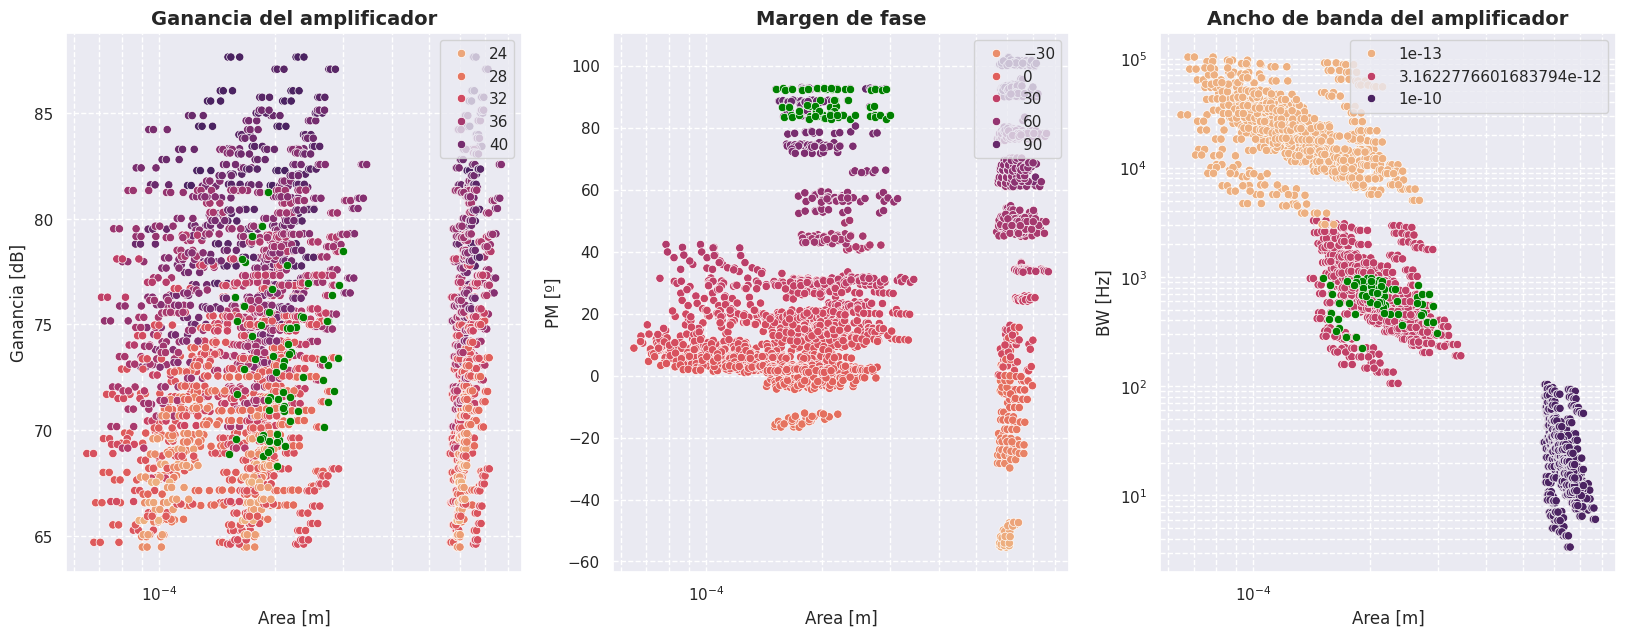

In [61]:
fig, axs = plt.subplots(1, 3, figsize=(20, 7))
sns.scatterplot(ax=axs[0], data=ota_df, x='area', y='gain', palette='flare', hue="gain_2stage")
sns.scatterplot(ax=axs[0], data=ota_df_new, x='area', y='gain', color="green")
sns.scatterplot(ax=axs[1], data=ota_df, x="area", y="phase_margin_OTA", hue="phase_margin_OTA_wc", palette='flare')
sns.scatterplot(ax=axs[1], data=ota_df_new, x="area", y="phase_margin_OTA", color="green")
sns.scatterplot(ax=axs[2], data=ota_df, x="area", y="bw", hue=Symbol("Cc"), hue_norm=LogNorm(), palette='flare')
sns.scatterplot(ax=axs[2], data=ota_df_new, x="area", y="bw", color="green")

axs[0].set_title(r"Ganancia del amplificador", fontsize=14, weight='bold')
axs[0].set_xlabel(r"Area [m]")
axs[0].set_ylabel(r"Ganancia [dB]")
axs[0].locator_params(axis='x', nbins=10) 
axs[0].legend(loc = 'upper right')

axs[1].set_title(r"Margen de fase", fontsize=14, weight='bold')
axs[1].set_xlabel(r"Area [m]")
axs[1].set_ylabel(r"PM [º]")
axs[1].legend(loc = 'upper right')

axs[2].set_xlabel(r"Area [m]")
axs[2].set_ylabel(r"BW [Hz]")
axs[2].set_title(r"Ancho de banda del amplificador", fontsize=14, weight='bold')
axs[2].legend(loc = 'upper right')

axs[0].grid(True,which="both",ls="--")  
axs[1].grid(True,which="both",ls="--")  
axs[2].grid(True,which="both",ls="--")  

axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[2].set_xscale('log')

axs[2].set_yscale('log')

#sns.move_legend(axs[0], "upper left",title="ganancia segunda etapa")

plt.savefig('ota_explore_raw_3_sky.pdf')

In [62]:
ota_df_new.to_csv("data/SKY_lv_ota_exploration3_case1_98_10_10.csv")
ota_df_wc_new.to_csv("data/SKY_lv_ota_exploration3_case2_98_10_10.csv")

# LDO

In [25]:
ota_df_new = pd.read_csv("data/SKY_lv_ota_exploration3_case1_98_10_10.csv")
ota_df_wc_new = pd.read_csv("data/SKY_lv_ota_exploration3_case2_98_10_10.csv")

In [26]:
OTA_primitive_wc = Primitive(
    parameters={
        Symbol("Ra"): ota_df_wc_new["rout_OTA"].values,
        Symbol("gma"): ota_df_wc_new["gm_OTA"].values,
        Symbol("Ra_1stage"): ota_df_wc_new[("Ra_1stage")].values,
        Symbol("gma_1stage"): ota_df_wc_new[("gma_1stage")].values,
        Symbol("Ra_2stage"): ota_df_wc_new[("Ra_2stage")].values,
        Symbol("gma_2stage"): ota_df_wc_new[("gma_2stage")].values,
        Symbol("Cin_2stage"): ota_df_wc_new[("Cin_2stage")].values,
        Symbol("Rc_2stage"): ota_df_wc_new[("Rc")].values,
        Symbol("Cc_2stage"): ota_df_wc_new[("Cc")].values,
    }
)

OTA_primitive_wc.outputs = {
    Symbol("W_2stage"): ota_df_wc_new[("W_2stage")].values,
    Symbol("L_2stage"): ota_df_wc_new[("L_2stage")].values,
    Symbol("vin_2stage"): ota_df_wc_new[("vin_2stage")].values,
    Symbol("W_cs_2stage"): ota_df_wc_new[("W_cs_2stage")].values,
    Symbol("L_cs_2stage"): ota_df_wc_new[("L_cs_2stage")].values,
    Symbol("vgs_cs_2stage"): ota_df_wc_new[("vgs_cs_2stage")].values,
    
    Symbol("W_diff"): ota_df_wc_new[("W_diff")].values,
    Symbol("L_diff"): ota_df_wc_new[("L_diff")].values,
    Symbol("vout_1stage"): ota_df_wc_new[("vout_1stage")].values,
    Symbol("W_al"): ota_df_wc_new[("W_al")].values,
    Symbol("L_al"): ota_df_wc_new[("L_al")].values,
    Symbol("W_cs"): ota_df_wc_new[("W_cs")].values,
    Symbol("L_cs"): ota_df_wc_new[("L_cs")].values,
    Symbol("vgs_cs"): ota_df_wc_new[("vgs_cs")].values,
}

In [90]:
ldo_df_new

,Ra,gma,Ra_1stage,gma_1stage,Ra_2stage,gma_2stage,Cin_2stage,Rc_2stage,Cc_2stage,gm_pt,...,gain_ol,psrr_wc,gain_ol_wc,Vota_wc,cin_pt_wc,gmid,phase_margin_LDO_wc,loadreg,bw,gain_ota
0,469879.338088,0.005928,1.429260e+06,0.000054,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,82.012892,-54.674103,76.727111,1.507593,0.114702,5.991094,89.983079,0.837809,956.116828,68.897474
1,469879.338088,0.005928,1.429260e+06,0.000054,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,82.012892,-54.674103,76.727111,1.507593,0.114702,5.991094,89.983138,0.837809,956.116828,68.897474
2,469879.338088,0.005928,1.429260e+06,0.000054,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,82.012892,-54.674103,76.727111,1.507593,0.114702,5.991094,89.983079,0.837809,956.116828,68.897474
3,469879.338088,0.005928,1.429260e+06,0.000054,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,82.012892,-54.674103,76.727111,1.507593,0.114702,5.991094,89.983138,0.837809,956.116828,68.897474
4,469879.338088,0.006428,1.635692e+06,0.000051,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,82.717074,-55.408705,77.461850,1.507593,0.114702,5.991094,89.980595,0.768911,835.450467,69.601656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,664535.860261,0.012590,3.024653e+06,0.000051,664535.860261,0.000082,8.370936e-14,100000.0,3.162278e-12,0.030405,...,91.566507,-64.358348,86.412491,1.507593,0.114702,5.991094,89.964283,0.273273,303.960997,78.451089
264,916312.845291,0.012590,3.024564e+06,0.000051,916312.845291,0.000082,8.370936e-14,100000.0,3.162278e-12,0.030405,...,94.357118,-65.055507,87.109693,1.507593,0.114702,5.991094,89.964222,0.271623,221.000574,81.241700
265,916312.845291,0.012590,3.024564e+06,0.000051,916312.845291,0.000082,8.370936e-14,100000.0,3.162278e-12,0.030405,...,94.357118,-65.055507,87.109693,1.507593,0.114702,5.991094,89.964281,0.271623,221.000574,81.241700
266,916312.845291,0.012590,3.024564e+06,0.000051,916312.845291,0.000082,8.370936e-14,100000.0,3.162278e-12,0.030405,...,94.357118,-65.055507,87.109693,1.507593,0.114702,5.991094,89.964222,0.271623,221.000574,81.241700


In [91]:
ldo_df_wc_new

,Ra,gma,Ra_1stage,gma_1stage,Ra_2stage,gma_2stage,Cin_2stage,Rc_2stage,Cc_2stage,gm_pt,...,L_cs,vgs_cs,W_pt,L_pt,W_cc,L_cc,W_rc,L_rc,area,gain_ol
0,134976.147829,0.005693,1.460403e+06,0.000054,134976.147829,0.000073,1.888351e-14,100000.0,3.162278e-12,0.001308,...,0.000006,0.7,0.000726,4.000000e-07,0.000008,0.000008,0.000001,5.000000e-07,0.000791,76.727111
1,134976.147829,0.005693,1.460403e+06,0.000054,134976.147829,0.000073,1.888351e-14,100000.0,3.162278e-12,0.001308,...,0.000006,0.7,0.000726,4.000000e-07,0.000015,0.000015,0.000001,5.000000e-07,0.000804,76.727111
2,134976.147829,0.005693,1.460403e+06,0.000054,134976.147829,0.000073,1.888351e-14,100000.0,3.162278e-12,0.001308,...,0.000006,0.7,0.000726,4.000000e-07,0.000026,0.000026,0.000001,5.000000e-07,0.000827,76.727111
3,134976.147829,0.005693,1.460403e+06,0.000054,134976.147829,0.000073,1.888351e-14,100000.0,3.162278e-12,0.001308,...,0.000006,0.7,0.000726,4.000000e-07,0.000008,0.000008,0.000002,5.000000e-07,0.000792,76.727111
4,134976.147829,0.006195,1.677295e+06,0.000051,134976.147829,0.000073,1.888351e-14,100000.0,3.162278e-12,0.001308,...,0.000006,0.7,0.000726,4.000000e-07,0.000008,0.000008,0.000001,5.000000e-07,0.000798,77.461850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,192963.656128,0.012145,3.039745e+06,0.000051,192963.656128,0.000078,8.849205e-14,100000.0,3.162278e-12,0.001308,...,0.000006,0.5,0.000726,4.000000e-07,0.000008,0.000008,0.000002,5.000000e-07,0.000939,86.412491
264,209088.622017,0.012145,3.039653e+06,0.000051,209088.622017,0.000078,8.849205e-14,100000.0,3.162278e-12,0.001308,...,0.000006,0.7,0.000726,4.000000e-07,0.000008,0.000008,0.000001,5.000000e-07,0.000831,87.109693
265,209088.622017,0.012145,3.039653e+06,0.000051,209088.622017,0.000078,8.849205e-14,100000.0,3.162278e-12,0.001308,...,0.000006,0.7,0.000726,4.000000e-07,0.000015,0.000015,0.000001,5.000000e-07,0.000843,87.109693
266,209088.622017,0.012145,3.039653e+06,0.000051,209088.622017,0.000078,8.849205e-14,100000.0,3.162278e-12,0.001308,...,0.000006,0.7,0.000726,4.000000e-07,0.000026,0.000026,0.000001,5.000000e-07,0.000866,87.109693


In [27]:
pt_2 = Primitive(
    parameters={
        Symbol('gm_pt'): np.asarray([0.0304048029485101]),
        Symbol('Ro_pt'): np.asarray([401.96637136321897]),
        Symbol("Cgg_pt"): np.asarray([1.567114848542521e-12]),
        Symbol("Cgd_pt"): np.asarray([7.650244072854094e-16]),
        Symbol("Cin_pt"): np.asarray([1.5764647537008622e-12]),
        Symbol("dropout"): np.asarray([0.333828836752825]),
        Symbol('Vota'): np.asarray([1.122222222222])
    }
)

pt_2.outputs = {
    Symbol("W_pt"): np.asarray([0.0007258641413085]),
    Symbol("L_pt"): np.asarray([4e-7])
}

pt_2_wc = Primitive(
    parameters={
        Symbol('gm_pt'): np.asarray([0.0013077388196833]),
        Symbol('Ro_pt'): np.asarray([11908.821884659845]),
        Symbol("Cgg_pt"): np.asarray([6.440992414275248e-13]),
        Symbol("Cgd_pt"): np.asarray([2.3663566049641697e-17]),
        Symbol("Cin_pt"): np.asarray([0.1147018026400135]),
        Symbol("dropout"): np.asarray([0.1147018026400135]),
        Symbol('Vota'): np.asarray([1.5075934460298])
    }
)

pt_2_wc.outputs = {
    Symbol("W_pt"): np.asarray([0.0007258641413085]),
    Symbol("L_pt"): np.asarray([4e-7])
}

In [28]:
Cc_primitive_LDO_2 = Primitive(
    parameters={
        Symbol("Cc"): np.asarray([3.1622776601683798e-12, 1e-12, 3.1622e-12, 1e-12]),
        Symbol("Rc"): np.asarray([1000.0, 1000, 3162, 3162])
    }
)

Cc_primitive_LDO_2.outputs = {
    Symbol("W_cc"): np.sqrt(Cc_primitive_LDO.parameters[Symbol("Cc")]/1.5e-15)*1e-6,
    Symbol("L_cc"): np.sqrt(Cc_primitive_LDO.parameters[Symbol("Cc")]/1.5e-15)*1e-6,
    Symbol("W_rc"): np.sqrt(Cc_primitive_LDO.parameters[Symbol("Rc")]/(1360*0.5))*1e-6,
    Symbol("L_rc"): np.repeat(0.5e-6, 4)
}

In [29]:
psrr_LDO_macro.parametros = {Symbol("V1"): 1,
                             Symbol("V2"): 0,
                             Symbol("s"): 0,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): 1000000000000,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2}

dc_LDO_macro.parametros = {Symbol("V1"): Vin,
                           Symbol("V2"): Vref,
                           Symbol("s"): 0,
                           Symbol("Rl"): 1000000000000,
                           Symbol("Cl"): CL,
                           Symbol("R1"): R1, 
                           Symbol("R2"): R2}

gain_ol_LDO_macro.parametros = {Symbol("V1"): 0,
                             Symbol("V2"): 0,
                             Symbol("V3"): 1,
                             Symbol("s"): 0,
                             Symbol("C1"): 10,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): 1000000000000,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2,
                             Symbol("R3"): 10000000000}

phase_margin_LDO_macro.tf = ["vout", "vol"]
phase_margin_LDO_macro.netlist = "ldo_ol_pm"
phase_margin_LDO_macro.parametros = {Symbol("V1"): 1,
                             Symbol("V2"): 0,
                             Symbol("V3"): 1,
                             Symbol("C1"): 10,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): 1000000000000,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2,
                             Symbol("R3"): 10000000000}

LDO_macro.ext_mask = None

LDO_macro.primitives = [OTA_primitive_wc, pt_2_wc, Cc_primitive_LDO_2]
LDO_macro.submacromodels = []
LDO_macro.num_level_exp = 1
LDO_macro.specifications = [psrr_LDO_macro, dc_LDO_macro, gain_ol_LDO_macro, phase_margin_LDO_macro]
LDO_macro.opt_specifications = [psrr_LDO_macro]
LDO_macro.is_primitive = 0
LDO_macro.run_pareto = False

_, _, _, ldo_df_wc, ldo_mask_wc = dfs(LDO_macro, debug = False)

############################################
Starting the exploration of:  LDO_macro
Netlist:  ldo
Running MNA... 
MNA of psrr_LDO took: 0.029931068420410156
   vdd  vout  net1  vfb  vss  net2
0    1     2     3    4    0     5
[['vout', 'vdd']]
Netlist:  ldo
Running MNA... 
MNA of dc_LDO took: 0.022626876831054688
   vdd  vout  net1  vfb  vss  net2
0    1     2     3    4    0     5
[['vout', 'vdd']]
Netlist:  ldo_ol
Running MNA... 
MNA of gain_ol_LDO took: 0.01931619644165039
   vss  vout  net1  vfb  vol  net2
0    0     1     2    3    4     5
[['vout', 'vol']]
Netlist:  ldo_ol_pm
Running MNA... 
MNA of phase_margin_LDO took: 0.025179386138916016
   vss  vout  net1  vfb  net2  vol  net4  net3
0    0     1     2    3     4    5     6     7
[['vout', 'vol']]
older order of submacros:  []
new order of submacros:  []
[]
in eval
(1.6e+16*Ro_pt*gm_pt + 1.6e+16)/(1.2e+16*Ra*Ro_pt*gm_pt*gma + 1000000016000.0*Ro_pt + 1.6e+16)
lambdify variables: (Ra, gma, Ra_1stage, gma_1stage, Ra_2stage, gm

In [30]:
OTA_primitive = Primitive(
    parameters={
        Symbol("Ra"): ota_df_new["rout_OTA"],
        Symbol("gma"): ota_df_new["gm_OTA"],
        Symbol("Ra_1stage"): ota_df_new[("Ra_1stage")],
        Symbol("gma_1stage"): ota_df_new[("gma_1stage")],
        Symbol("Ra_2stage"): ota_df_new[("Ra_2stage")],
        Symbol("gma_2stage"): ota_df_new[("gma_2stage")],
        Symbol("Cin_2stage"): ota_df_new[("Cin_2stage")],
        Symbol("Rc_2stage"): ota_df_new[("Rc")],
        Symbol("Cc_2stage"): ota_df_new[("Cc")],
    }
)

OTA_primitive.outputs = {
    Symbol("W_2stage"): ota_df_new[("W_2stage")].values,
    Symbol("L_2stage"): ota_df_new[("L_2stage")].values,
    Symbol("vin_2stage"): ota_df_new[("vin_2stage")].values,
    Symbol("W_cs_2stage"): ota_df_new[("W_cs_2stage")].values,
    Symbol("L_cs_2stage"): ota_df_new[("L_cs_2stage")].values,
    Symbol("vgs_cs_2stage"): ota_df_new[("vgs_cs_2stage")].values,
    
    Symbol("W_diff"): ota_df_new[("W_diff")].values,
    Symbol("L_diff"): ota_df_new[("L_diff")].values,
    Symbol("vout_1stage"): ota_df_new[("vout_1stage")].values,
    Symbol("W_al"): ota_df_new[("W_al")].values,
    Symbol("L_al"): ota_df_new[("L_al")].values,
    Symbol("W_cs"): ota_df_new[("W_cs")].values,
    Symbol("L_cs"): ota_df_new[("L_cs")].values,
    Symbol("vgs_cs"): ota_df_new[("vgs_cs")].values,
}

In [31]:
psrr_LDO_macro.parametros = {Symbol("V1"): 1,
                             Symbol("V2"): 0,
                             Symbol("s"): 0,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): RL,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2}

dc_LDO_macro.parametros = {Symbol("V1"): Vin,
                           Symbol("V2"): Vref,
                           Symbol("s"): 0,
                           Symbol("Rl"): RL,
                           Symbol("Cl"): CL,
                           Symbol("R1"): R1, 
                           Symbol("R2"): R2}

gain_ol_LDO_macro.parametros = {Symbol("V1"): 0,
                             Symbol("V2"): 0,
                             Symbol("V3"): 1,
                             Symbol("s"): 0,
                             Symbol("C1"): 10,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): RL,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2,
                             Symbol("R3"): 10000000000}

phase_margin_LDO_macro.tf = ["vout", "vol"]
phase_margin_LDO_macro.netlist = "ldo_ol_pm"
phase_margin_LDO_macro.parametros = {Symbol("V1"): 1,
                             Symbol("V2"): 0,
                             Symbol("V3"): 1,
                             Symbol("C1"): 10,
                             Symbol("Cl"): CL,
                             Symbol("Rl"): RL,
                             Symbol("R1"): R1, 
                             Symbol("R2"): R2,
                             Symbol("R3"): 10000000000}


LDO_macro.ext_mask = ldo_mask_wc

LDO_macro.primitives = [OTA_primitive, pt_2, Cc_primitive_LDO_2]
LDO_macro.submacromodels = []
LDO_macro.num_level_exp = 1
LDO_macro.specifications = [psrr_LDO_macro, dc_LDO_macro, gain_ol_LDO_macro, phase_margin_LDO_macro]
LDO_macro.opt_specifications = [psrr_LDO_macro]
LDO_macro.is_primitive = 0
LDO_macro.run_pareto = False

_, _, _, ldo_df, _ = dfs(LDO_macro, debug = False)

############################################
Starting the exploration of:  ldo_ol_pm
Netlist:  ldo
Running MNA... 
MNA of psrr_LDO took: 0.03182339668273926
   vdd  vout  net1  vfb  vss  net2
0    1     2     3    4    0     5
[['vout', 'vdd']]
Netlist:  ldo
Running MNA... 
MNA of dc_LDO took: 0.02193737030029297
   vdd  vout  net1  vfb  vss  net2
0    1     2     3    4    0     5
[['vout', 'vdd']]
Netlist:  ldo_ol
Running MNA... 
MNA of gain_ol_LDO took: 0.022579669952392578
   vss  vout  net1  vfb  vol  net2
0    0     1     2    3    4     5
[['vout', 'vol']]
Netlist:  ldo_ol_pm
Running MNA... 
MNA of phase_margin_LDO took: 0.0303647518157959
   vss  vout  net1  vfb  net2  vol  net4  net3
0    0     1     2    3     4    5     6     7
[['vout', 'vol']]
older order of submacros:  []
new order of submacros:  []
[]
in eval
(3840000.0*Ro_pt*gm_pt + 3840000.0)/(2880000.0*Ra*Ro_pt*gm_pt*gma + 16240.0*Ro_pt + 3840000.0)
lambdify variables: (Ra, gma, Ra_1stage, gma_1stage, Ra_2stage, gma_2

In [32]:
ldo_df["psrr"] = 20*np.log10(ldo_df["psrr_LDO"])
ldo_df["gain_ol"] = 20*np.log10(ldo_df["gain_ol_LDO"])  
ldo_df_new = ldo_df[(ldo_df[Symbol("dropout")]<0.4) & (ldo_df["phase_margin_LDO"]>60) & (ldo_df["phase_margin_LDO"]<100)]
ldo_df_new

,Ra,gma,Ra_1stage,gma_1stage,Ra_2stage,gma_2stage,Cin_2stage,Rc_2stage,Cc_2stage,gm_pt,...,vgs_cs,W_pt,L_pt,W_cc,L_cc,W_rc,L_rc,area,psrr,gain_ol
0,469879.338088,0.005928,1.429260e+06,0.000054,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,0.7,0.000726,4.000000e-07,0.000008,0.000008,0.000001,5.000000e-07,0.000791,-65.716505,82.012892
1,469879.338088,0.005928,1.429260e+06,0.000054,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,0.7,0.000726,4.000000e-07,0.000015,0.000015,0.000001,5.000000e-07,0.000804,-65.716505,82.012892
3,469879.338088,0.005928,1.429260e+06,0.000054,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,0.7,0.000726,4.000000e-07,0.000008,0.000008,0.000002,5.000000e-07,0.000792,-65.716505,82.012892
4,469879.338088,0.006428,1.635692e+06,0.000051,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,0.7,0.000726,4.000000e-07,0.000008,0.000008,0.000001,5.000000e-07,0.000798,-66.420615,82.717074
5,469879.338088,0.006428,1.635692e+06,0.000051,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,0.7,0.000726,4.000000e-07,0.000015,0.000015,0.000001,5.000000e-07,0.000811,-66.420615,82.717074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,559764.342070,0.012590,3.024625e+06,0.000051,559764.342070,0.000082,8.370936e-14,100000.0,3.162278e-12,0.030405,...,0.5,0.000726,4.000000e-07,0.000026,0.000026,0.000001,5.000000e-07,0.000918,-73.779333,90.076276
260,664535.860261,0.012590,3.024653e+06,0.000051,664535.860261,0.000082,8.370936e-14,100000.0,3.162278e-12,0.030405,...,0.5,0.000726,4.000000e-07,0.000008,0.000008,0.000001,5.000000e-07,0.000938,-75.269506,91.566507
262,664535.860261,0.012590,3.024653e+06,0.000051,664535.860261,0.000082,8.370936e-14,100000.0,3.162278e-12,0.030405,...,0.5,0.000726,4.000000e-07,0.000026,0.000026,0.000001,5.000000e-07,0.000974,-75.269506,91.566507
264,916312.845291,0.012590,3.024564e+06,0.000051,916312.845291,0.000082,8.370936e-14,100000.0,3.162278e-12,0.030405,...,0.7,0.000726,4.000000e-07,0.000008,0.000008,0.000001,5.000000e-07,0.000831,-78.060034,94.357118


In [33]:
ldo_df["psrr"] = 20*np.log10(ldo_df["psrr_LDO"])
ldo_df["psrr_wc"] = 20*np.log10(ldo_df_wc["psrr_LDO"])

ldo_df['gain_ol'] = 20*np.log10(ldo_df['gain_ol_LDO'])
ldo_df['gain_ol_wc'] = 20*np.log10(ldo_df_wc['gain_ol_LDO'])

ldo_df["Vota_wc"] = ldo_df_wc[Symbol("Vota")]
ldo_df["cin_pt_wc"] = ldo_df_wc[Symbol("Cin_pt")]

ldo_df['gmid'] = ldo_df[Symbol('gm_pt')]/pt.inputs['il']

ldo_df["phase_margin_LDO_wc"] = ldo_df_wc["phase_margin_LDO"]

ldo_df['loadreg'] = np.abs(ldo_df['dc_LDO']-ldo_df_wc['dc_LDO'])/IL

ldo_df["bw"] = 1/(2*np.pi*ldo_df[Symbol("Ra_1stage")]*(ldo_df[Symbol("Cin_pt")]+ldo_df[Symbol("gma_2stage")]*ldo_df[Symbol("Ra_2stage")]*ldo_df[Symbol("Cc_2stage")]))    
ldo_df["gain_ota"] = 20*np.log10(ldo_df[Symbol("Ra")]*ldo_df[Symbol("gma")])

#ldo_df = ldo_df[(ldo_df["gain_ota"]>20) & (ldo_df[Symbol("W_pt")]<0.6e-3) & (ldo_df[Symbol("dropout")]<0.4)]

ldo_df_new = ldo_df[((ldo_df[Symbol("dropout")]<0.4) & (ldo_df["psrr"]<-60) & (ldo_df["phase_margin_LDO_wc"]>60) & (ldo_df["bw"]>10) & (ldo_df[Symbol("W_pt")]<1e-3) & (ldo_df["loadreg"]<1) )]
#ldo_df_new = ldo_df
ldo_df_new.sort_values(by="area")

,Ra,gma,Ra_1stage,gma_1stage,Ra_2stage,gma_2stage,Cin_2stage,Rc_2stage,Cc_2stage,gm_pt,...,gain_ol,psrr_wc,gain_ol_wc,Vota_wc,cin_pt_wc,gmid,phase_margin_LDO_wc,loadreg,bw,gain_ota
0,469879.338088,0.005928,1.429260e+06,0.000054,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,82.012892,-54.674103,76.727111,1.507593,0.114702,5.991094,89.983079,0.456987,956.116828,68.897474
3,469879.338088,0.005928,1.429260e+06,0.000054,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,82.012892,-54.674103,76.727111,1.507593,0.114702,5.991094,89.983138,0.456987,956.116828,68.897474
4,469879.338088,0.006428,1.635692e+06,0.000051,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,82.717074,-55.408705,77.461850,1.507593,0.114702,5.991094,89.980595,0.419406,835.450467,69.601656
20,916312.845291,0.006258,1.429260e+06,0.000054,916312.845291,0.000082,8.370936e-14,100000.0,3.162278e-12,0.030405,...,88.284887,-59.031151,81.084825,1.507593,0.114702,5.991094,89.982893,0.296016,467.675857,75.169468
7,469879.338088,0.006428,1.635692e+06,0.000051,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,82.717074,-55.408705,77.461850,1.507593,0.114702,5.991094,89.980654,0.419406,835.450467,69.601656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,664535.860261,0.009910,2.383495e+06,0.000051,664535.860261,0.000082,8.370936e-14,100000.0,3.162278e-12,0.030405,...,89.487151,-62.305191,84.359186,1.507593,0.114702,5.991094,89.971680,0.188600,385.726372,76.371733
182,393439.738524,0.009926,2.385487e+06,0.000054,393439.738524,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,84.948368,-58.572416,80.626035,1.507593,0.114702,5.991094,89.972283,0.279680,682.358718,71.832950
206,393439.738524,0.011926,3.024653e+06,0.000051,393439.738524,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,86.542857,-60.190300,82.244102,1.507593,0.114702,5.991094,89.964812,0.231891,538.163327,73.427439
238,664535.860261,0.010479,2.385487e+06,0.000054,664535.860261,0.000082,8.370936e-14,100000.0,3.162278e-12,0.030405,...,89.972018,-62.752668,84.806698,1.507593,0.114702,5.991094,89.971778,0.179408,385.404256,76.856599


In [34]:
ldo_df_wc_new = ldo_df_wc[((ldo_df[Symbol("dropout")]<0.4) & (ldo_df["psrr"]<-60) & (ldo_df["phase_margin_LDO_wc"]>60) & (ldo_df["bw"]>100) & (ldo_df[Symbol("W_pt")]<1e-3)  & (ldo_df["loadreg"]<1))]
ldo_df_wc_new['gain_ol'] = 20*np.log10(ldo_df_wc['gain_ol_LDO'])

/tmp/ipykernel_20233/882397663.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ldo_df_wc_new['gain_ol'] = 20*np.log10(ldo_df_wc['gain_ol_LDO'])


In [35]:
pareto_dict = {"area": ldo_df_new["area"].values, "pm": ldo_df_new["phase_margin_LDO_wc"].values}
pareto_df = pd.DataFrame(pareto_dict)

mask = pareto.paretoset(pareto_df, sense=["min", "max"])

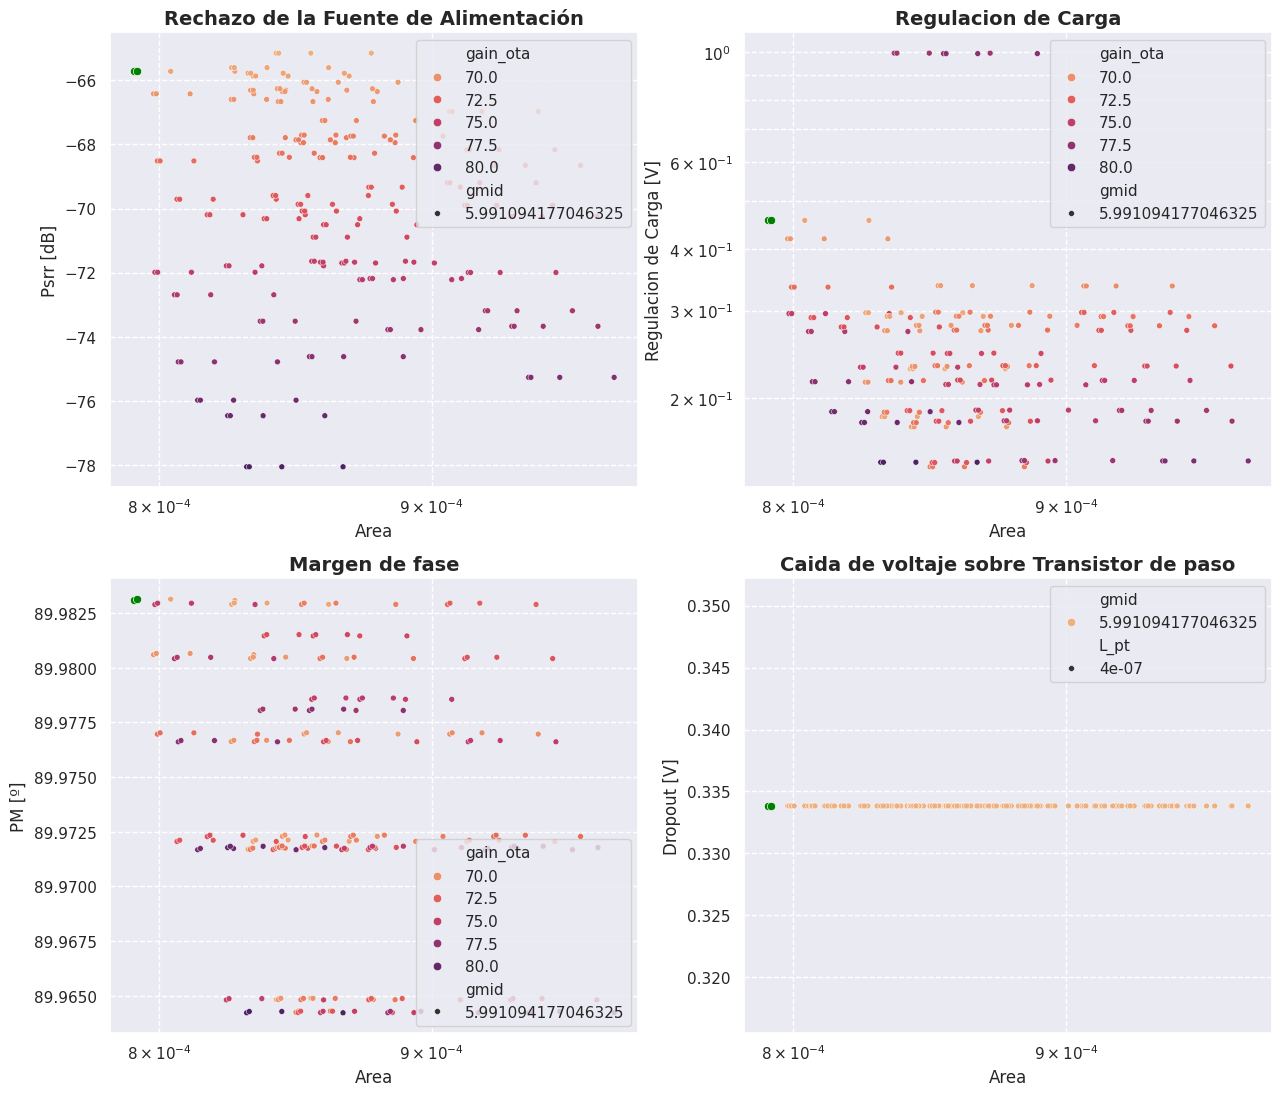

In [36]:
fig, axs = plt.subplots(2, 2, figsize=(15, 13))
sns.scatterplot(ax=axs[0,0], data=ldo_df_new, x='area', y='psrr', palette='flare', hue='gain_ota', rasterized=True, size='gmid')
sns.scatterplot(ax=axs[0,0], data=ldo_df_new[mask], x='area', y='psrr', c='green')
sns.scatterplot(ax=axs[0,1], data=ldo_df_new, x='area', y='loadreg', palette='flare', rasterized=True, hue='gain_ota', size='gmid')
sns.scatterplot(ax=axs[0,1], data=ldo_df_new[mask], x='area', y='loadreg', c='green')
sns.scatterplot(ax=axs[1,1], data=ldo_df_new, x='area', y=Symbol('dropout'), palette='flare', hue='gmid', rasterized=True, size=Symbol('L_pt'))
sns.scatterplot(ax=axs[1,1], data=ldo_df_new[mask], x='area', y=Symbol('dropout'), c='green')
sns.scatterplot(ax=axs[1,0], data=ldo_df_new, x='area', y="phase_margin_LDO_wc", palette='flare', hue="gain_ota", rasterized=True, size='gmid')
sns.scatterplot(ax=axs[1,0], data=ldo_df_new[mask], x='area', y="phase_margin_LDO_wc", c='green')

axs[0,0].set_title(r"Rechazo de la Fuente de Alimentación", fontsize=14, weight='bold')
axs[0,0].set_xlabel(r"Area")
axs[0,0].set_ylabel(r"Psrr [dB]")
axs[0,0].locator_params(axis='x', nbins=10) 
axs[0,0].legend(loc = 'upper right')

axs[0,1].set_title(r"Regulacion de Carga", fontsize=14, weight='bold')
axs[0,1].set_xlabel(r"Area")
axs[0,1].set_ylabel(r"Regulacion de Carga [V]")
axs[0,1].legend(loc = 'upper right')

axs[1,1].set_xlabel(r"Area")
axs[1,1].set_ylabel(r"Dropout [V]")
axs[1,1].set_title(r"Caida de voltaje sobre Transistor de paso", fontsize=14, weight='bold')
axs[1,1].legend(loc = 'upper right')

axs[1,0].set_title(r"Margen de fase", fontsize=14, weight='bold')
axs[1,0].set_xlabel(r"Area")
axs[1,0].set_ylabel(r"PM [º]")
axs[1,0].legend(loc = 'upper right')
#fig.suptitle(r"Ganancias intrínsecas", fontsize=24, y=1.1)

axs[0,0].set_xscale('log')
axs[0,1].set_xscale('log')
axs[1,0].set_xscale('log')
axs[1,1].set_xscale('log')

axs[0,1].set_yscale('log')



axs[0,0].grid(True,which="both",ls="--")  
axs[0,1].grid(True,which="both",ls="--")  
axs[1,0].grid(True,which="both",ls="--")  
axs[1,1].grid(True,which="both",ls="--")  

sns.move_legend(axs[0,0], "upper right")
sns.move_legend(axs[0,1], "upper right")
sns.move_legend(axs[1,0], "lower right")
sns.move_legend(axs[1,1], "upper right")

plt.savefig('ldo_explore_raw_2_sky.pdf')

In [37]:
ldo_df_new[mask].to_csv("data/SKY_lv_ldo_final_98_10_10.csv")

In [38]:
ldo_df_new[mask]

,Ra,gma,Ra_1stage,gma_1stage,Ra_2stage,gma_2stage,Cin_2stage,Rc_2stage,Cc_2stage,gm_pt,...,gain_ol,psrr_wc,gain_ol_wc,Vota_wc,cin_pt_wc,gmid,phase_margin_LDO_wc,loadreg,bw,gain_ota
0,469879.338088,0.005928,1.429260e+06,0.000054,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,82.012892,-54.674103,76.727111,1.507593,0.114702,5.991094,89.983079,0.456987,956.116828,68.897474
3,469879.338088,0.005928,1.429260e+06,0.000054,469879.338088,0.000077,1.781634e-14,100000.0,3.162278e-12,0.030405,...,82.012892,-54.674103,76.727111,1.507593,0.114702,5.991094,89.983138,0.456987,956.116828,68.897474
